# Statistical MFCC and Gaussian-Mixture Analysis of the FM ROI

This notebook loads the `97-99 MHz` region of interest (ROI) from each `data/acquisitions/Node*.csv` file, skips `Node9`, and overlays the **first ROI-intersecting acquisition** of the remaining sensors.

The first analysis builds MFCC statistics from **all ROI-intersecting acquisitions** of the kept sensors. The retained MFCC count is chosen automatically as the smallest number of coefficients whose `95%` confidence lower bound for cumulative cepstral energy reaches `95%`, and the notebook renders the original five-panel MFCC dashboard with the ROI overlay, the per-sensor retained MFCC profiles, the mean sensor-correlation matrix, the realization-wise correlation-strength trajectories, and a confidence-aware sensor ranking derived from the per-sensor absolute-correlation sums.

The second analysis reuses the statistically retained MFCC vectors, fits a global diagonal Gaussian mixture with a BIC-selected component count, and maps each acquisition to its posterior responsibility profile. The notebook then adds the GMM component-selection curve and a second five-panel dashboard in responsibility space with per-sensor profiles, mean sensor correlations, realization-wise correlation-strength trajectories, and a confidence-aware sensor ranking.


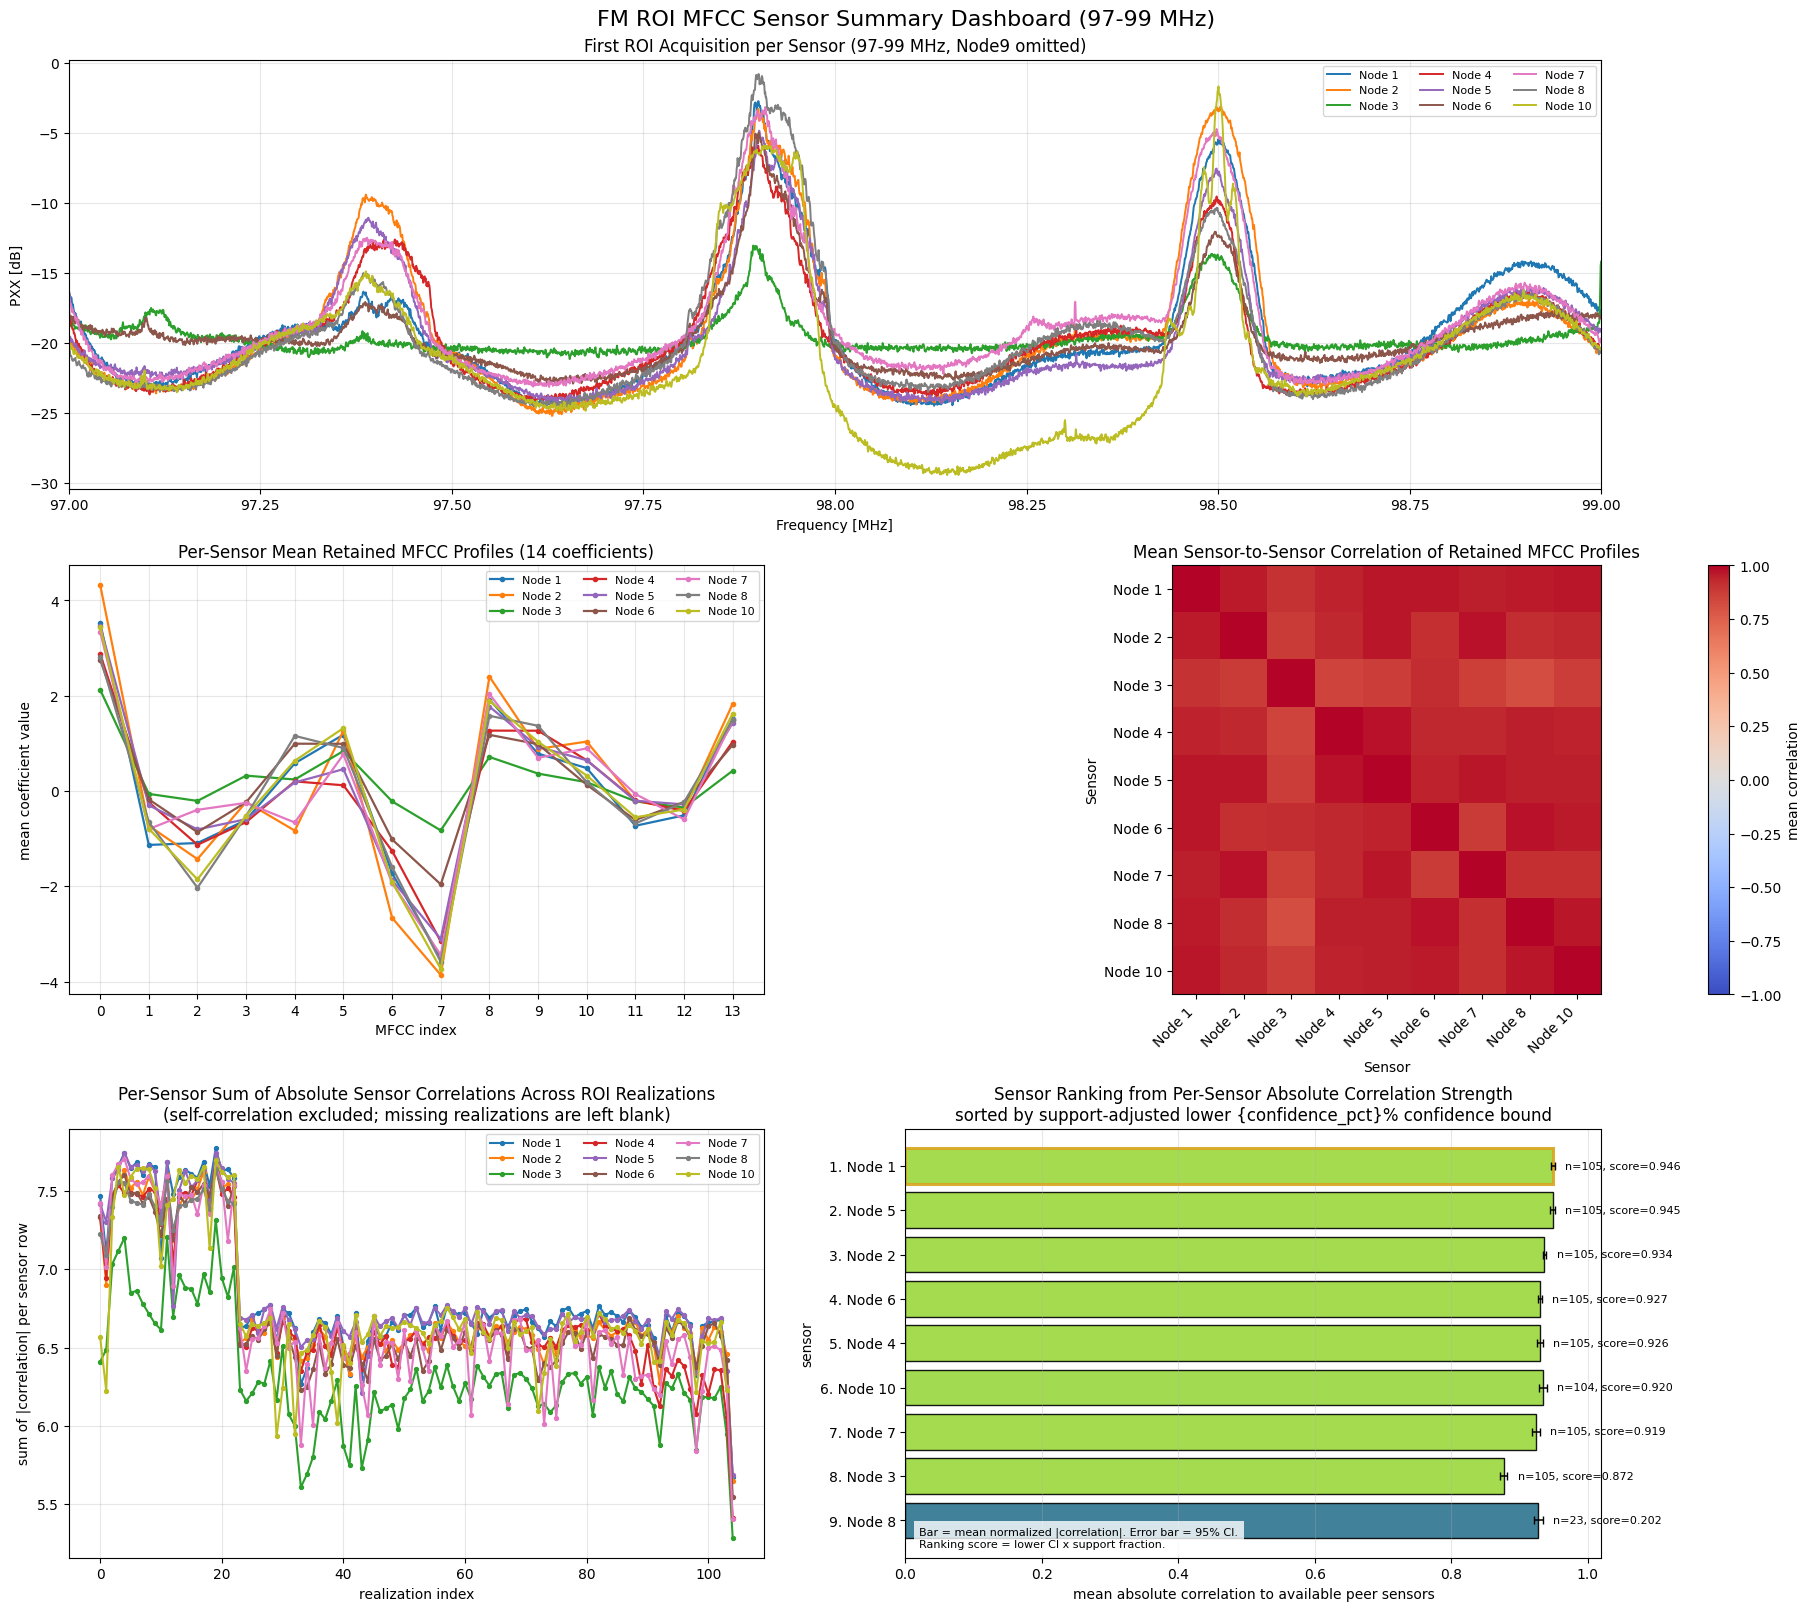

Selected global diagonal GMM with 6 components by minimum BIC; best restart converged=True, iterations=27.


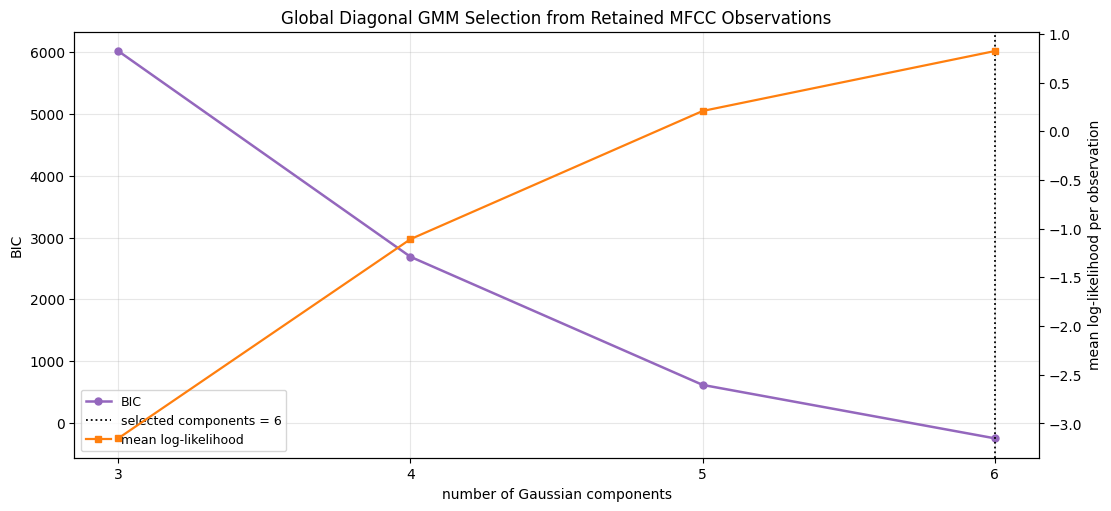

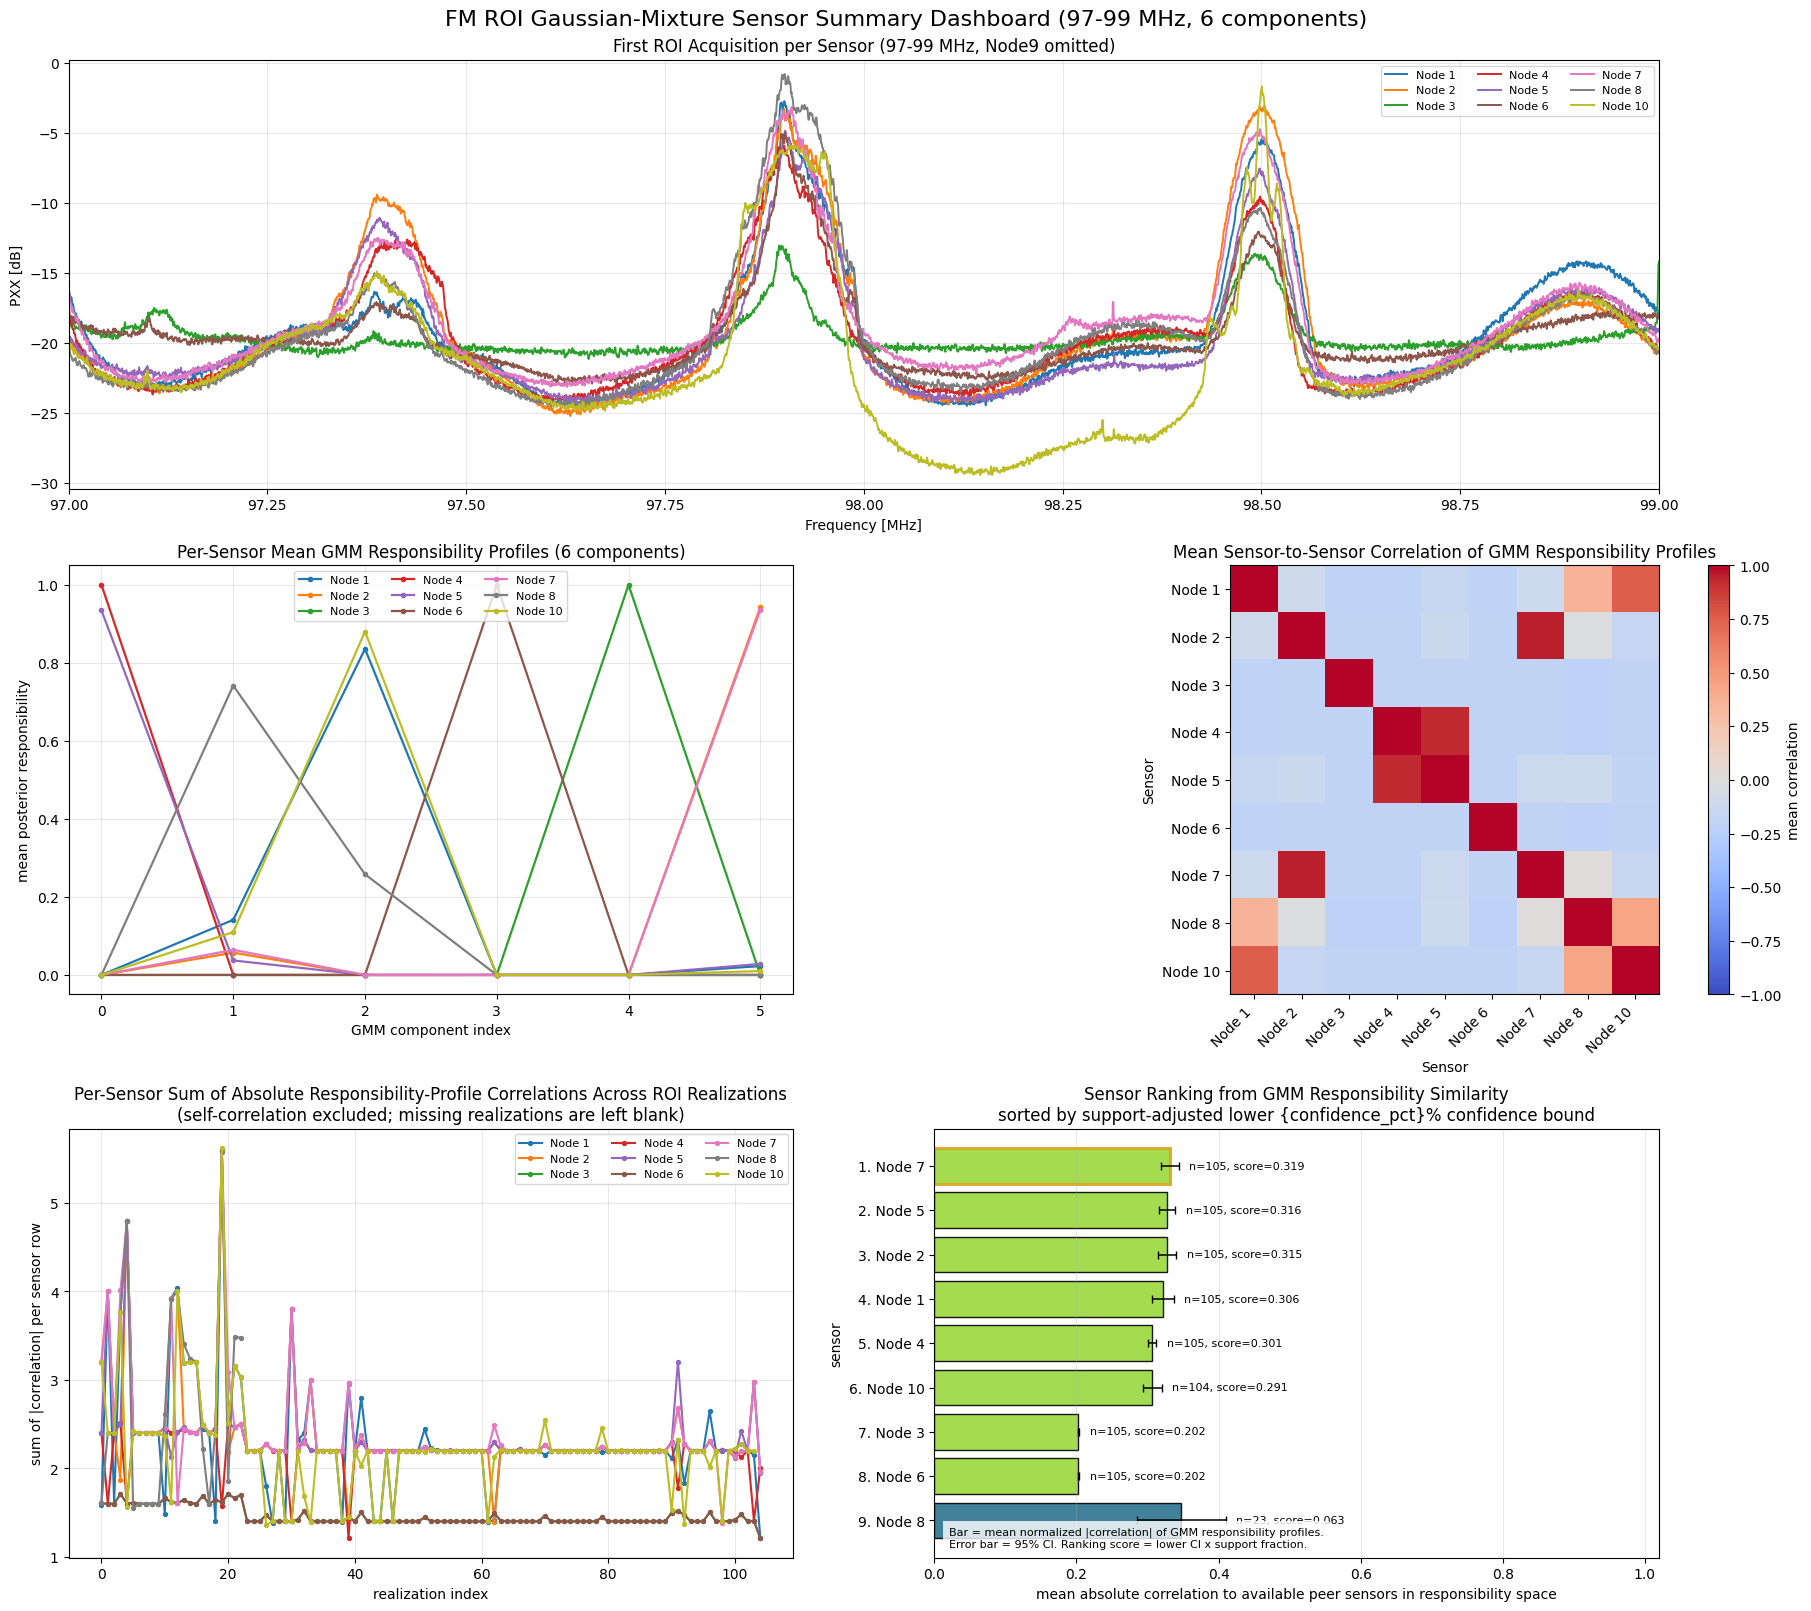

In [1]:
from __future__ import annotations

import csv
import re
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import dct
from scipy.special import logsumexp
from scipy.stats import t

try:
    from IPython import get_ipython
except ImportError:  # pragma: no cover - notebook execution provides IPython.
    get_ipython = None

csv.field_size_limit(10**9)
warnings.filterwarnings(
    "ignore",
    message="FigureCanvasAgg is non-interactive, and thus cannot be shown",
    category=UserWarning,
)

if get_ipython is not None:
    # Keep notebook execution headless while still emitting inline figures in the saved output.
    current_ipython = get_ipython()
    if current_ipython is not None:
        current_ipython.run_line_magic("matplotlib", "inline")

ROI_START_MHZ = 97.0
ROI_END_MHZ = 99.0
SKIPPED_SENSOR_INDICES = frozenset({9})
NUM_MEL_BANDS = 24
ENERGY_CAPTURE_THRESHOLD = 0.95
CONFIDENCE_LEVEL = 0.95
MFCC_LOG_EPS = 1.0e-10
GMM_MIN_COMPONENTS = 3
GMM_MAX_COMPONENTS = 6
GMM_NUM_INITIALIZATIONS = 6
GMM_MAX_ITERATIONS = 250
GMM_CONVERGENCE_TOL = 1.0e-4
GMM_VARIANCE_FLOOR_RATIO = 1.0e-3
GMM_RANDOM_SEED = 7


@dataclass(frozen=True)
class SensorRoiAcquisitionSeries:
    """All ROI-intersecting acquisitions loaded from one sensor CSV file.

    Attributes
    ----------
    sensor_index:
        Numeric sensor identifier extracted from the filename.
    location:
        Location label encoded in the filename.
    roi_frequency_hz:
        Shared frequency axis for the kept ROI samples [Hz].
    roi_traces_db:
        ROI traces with shape `(num_plotted_acquisitions, num_roi_bins)` in dB.
    total_acquisitions:
        Number of acquisitions available in the CSV file.
    plotted_acquisitions:
        Number of acquisitions whose band intersects the requested ROI.
    available_bands_mhz:
        Sorted list of unique acquisition bands observed in the file [MHz].
    """

    sensor_index: int
    location: str
    roi_frequency_hz: np.ndarray
    roi_traces_db: np.ndarray
    total_acquisitions: int
    plotted_acquisitions: int
    available_bands_mhz: tuple[tuple[float, float], ...]


@dataclass(frozen=True)
class RoiMfccObservation:
    """MFCC observation derived from one ROI-intersecting acquisition.

    Attributes
    ----------
    sensor_index:
        Numeric sensor identifier used to group repeated acquisitions.
    location:
        Location label encoded in the filename.
    acquisition_index:
        Zero-based index of the acquisition within the sensor CSV file.
    mel_log_energies:
        Log-mel energy vector computed from the ROI spectrum.
    full_cepstral_coefficients:
        Full DCT-II cepstral vector before truncation.
    """

    sensor_index: int
    location: str
    acquisition_index: int
    mel_log_energies: np.ndarray
    full_cepstral_coefficients: np.ndarray


@dataclass(frozen=True)
class SensorFeatureObservation:
    """Feature vector associated with one ROI-intersecting acquisition.

    Attributes
    ----------
    sensor_index:
        Numeric sensor identifier used to group repeated acquisitions.
    location:
        Location label encoded in the filename.
    acquisition_index:
        Zero-based index of the acquisition within the sensor CSV file.
    feature_vector:
        One-dimensional feature vector derived from the ROI acquisition.
    """

    sensor_index: int
    location: str
    acquisition_index: int
    feature_vector: np.ndarray


@dataclass(frozen=True)
class MfccStatisticalSelection:
    """Statistical evidence used to choose a sufficient MFCC count.

    Attributes
    ----------
    selected_n_mfcc:
        Smallest MFCC count whose lower confidence bound reaches the target.
    mean_cumulative_energy_ratio:
        Mean retained cepstral energy ratio for each candidate coefficient count.
    lower_cumulative_energy_ratio:
        Lower confidence bound of the cumulative energy ratio.
    upper_cumulative_energy_ratio:
        Upper confidence bound of the cumulative energy ratio.
    confidence_level:
        Confidence level used for the interval construction.
    energy_capture_threshold:
        Target cumulative cepstral energy ratio used for selection.
    num_observations:
        Number of ROI acquisitions contributing to the statistical estimate.
    """

    selected_n_mfcc: int
    mean_cumulative_energy_ratio: np.ndarray
    lower_cumulative_energy_ratio: np.ndarray
    upper_cumulative_energy_ratio: np.ndarray
    confidence_level: float
    energy_capture_threshold: float
    num_observations: int


@dataclass(frozen=True)
class MfccGlobalStatistics:
    """Aggregate statistics of the retained MFCC coefficients.

    Attributes
    ----------
    coefficient_mean:
        Mean MFCC value for each retained coefficient across all acquisitions.
    coefficient_lower_ci:
        Lower confidence bound for each retained coefficient.
    coefficient_upper_ci:
        Upper confidence bound for each retained coefficient.
    coefficient_correlation:
        Correlation matrix of the retained MFCC coefficients.
    """

    coefficient_mean: np.ndarray
    coefficient_lower_ci: np.ndarray
    coefficient_upper_ci: np.ndarray
    coefficient_correlation: np.ndarray


@dataclass(frozen=True)
class DiagonalGaussianMixtureModel:
    """Diagonal-covariance Gaussian mixture fitted on retained MFCC vectors.

    Attributes
    ----------
    component_weights:
        Mixture weights that sum to one.
    component_means:
        Mean vector of each Gaussian component with shape `(num_components, feature_dim)`.
    component_variances:
        Diagonal variance vector of each component with the same shape as `component_means`.
    total_log_likelihood:
        Final summed data log-likelihood under the fitted model.
    num_iterations:
        Number of EM iterations performed by the selected restart.
    converged:
        Whether the EM updates satisfied the configured convergence tolerance.
    """

    component_weights: np.ndarray
    component_means: np.ndarray
    component_variances: np.ndarray
    total_log_likelihood: float
    num_iterations: int
    converged: bool


@dataclass(frozen=True)
class GmmComponentSelection:
    """Model-selection evidence for the global diagonal Gaussian mixture.

    Attributes
    ----------
    selected_num_components:
        Number of Gaussian components chosen by the minimum BIC criterion.
    candidate_component_counts:
        Component counts evaluated during model selection.
    bic_values:
        Bayesian Information Criterion value for each candidate component count.
    average_log_likelihoods:
        Mean log-likelihood per observation for each candidate component count.
    selected_model:
        Fitted diagonal Gaussian mixture associated with the selected component count.
    """

    selected_num_components: int
    candidate_component_counts: np.ndarray
    bic_values: np.ndarray
    average_log_likelihoods: np.ndarray
    selected_model: DiagonalGaussianMixtureModel


@dataclass(frozen=True)
class SensorCorrelationSummary:
    """Sensor-level feature correlation summaries across aligned ROI realizations.

    Attributes
    ----------
    sensor_labels:
        Ordered sensor labels used on both correlation plots.
    mean_sensor_correlation:
        Mean sensor-to-sensor correlation matrix averaged across realizations.
    realization_indices:
        Sorted realization indices used to build the dynamic correlation trajectories.
    row_abs_correlation_sums:
        Sum of absolute sensor correlations per realization and per sensor row.
        The array shape is `(num_sensors, num_realizations)`, self-correlation is excluded,
        and missing sensor-realization pairs are stored as `NaN`.
    available_sensor_counts:
        Number of sensors contributing to each realization-level correlation matrix.
    """

    sensor_labels: list[str]
    mean_sensor_correlation: np.ndarray
    realization_indices: np.ndarray
    row_abs_correlation_sums: np.ndarray
    available_sensor_counts: np.ndarray


@dataclass(frozen=True)
class SensorCorrelationRanking:
    """Ranked sensor summary derived from realization-wise absolute correlation row sums.

    Attributes
    ----------
    ranked_sensor_labels:
        Sensor labels sorted from the strongest to the weakest ranking score.
    mean_normalized_abs_correlation:
        Mean absolute correlation to the available peer sensors after normalizing each
        realization by its peer count, so the metric stays on `[0, 1]`.
    lower_confidence_bound:
        Lower confidence bound of the normalized mean absolute correlation.
    upper_confidence_bound:
        Upper confidence bound of the normalized mean absolute correlation.
    informative_realization_counts:
        Number of realizations with at least one peer sensor that contribute to the ranking.
    support_fractions:
        Fraction of informative realizations supporting each sensor estimate.
    ranking_scores:
        Confidence-aware ranking score `lower_confidence_bound * support_fractions`.
    confidence_level:
        Confidence level used to build the ranking intervals.
    """

    ranked_sensor_labels: list[str]
    mean_normalized_abs_correlation: np.ndarray
    lower_confidence_bound: np.ndarray
    upper_confidence_bound: np.ndarray
    informative_realization_counts: np.ndarray
    support_fractions: np.ndarray
    ranking_scores: np.ndarray
    confidence_level: float


def find_repository_root(start_dir: Path) -> Path:
    """Return the repository root by locating the acquisitions directory.

    Parameters
    ----------
    start_dir:
        Directory from which the upward search begins.

    Returns
    -------
    Path
        Repository root that contains `data/acquisitions`.

    Raises
    ------
    FileNotFoundError
        If the notebook is executed outside this repository tree.
    """

    for candidate in (start_dir, *start_dir.parents):
        if (candidate / "data" / "acquisitions").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root containing data/acquisitions."
    )


def extract_sensor_index(csv_path: Path) -> int:
    """Extract the numeric sensor index from a file named like `Node10-Bogota.csv`."""

    match = re.match(r"Node(\d+)-", csv_path.stem)
    if match is None:
        raise ValueError(f"Unexpected sensor filename: {csv_path.name}")

    return int(match.group(1))


def build_frequency_axis_hz(
    start_freq_hz: float,
    end_freq_hz: float,
    num_points: int,
) -> np.ndarray:
    """Build the uniform frequency axis for one acquisition.

    The spectrum bins are assumed to cover the half-open interval
    `[start_freq_hz, end_freq_hz)` with constant spacing.

    Parameters
    ----------
    start_freq_hz:
        Lower edge of the measured frequency range [Hz].
    end_freq_hz:
        Upper edge of the measured frequency range [Hz].
    num_points:
        Number of spectral samples stored in each `pxx` trace.

    Returns
    -------
    np.ndarray
        Frequency axis with one value per spectral sample.

    Raises
    ------
    ValueError
        If the provided range or sample count is invalid.
    """

    if num_points <= 0:
        raise ValueError("num_points must be strictly positive.")
    if not np.isfinite(start_freq_hz) or not np.isfinite(end_freq_hz):
        raise ValueError("Frequency bounds must be finite numeric values.")
    if end_freq_hz <= start_freq_hz:
        raise ValueError("end_freq_hz must be strictly larger than start_freq_hz.")

    return np.linspace(start_freq_hz, end_freq_hz, num_points, endpoint=False)


def parse_pxx_trace(pxx_literal: str, csv_name: str) -> np.ndarray:
    """Parse one serialized `pxx` field into a validated 1D float32 array.

    Parameters
    ----------
    pxx_literal:
        Serialized Python-style list stored in the CSV file.
    csv_name:
        CSV filename used to produce actionable validation errors.

    Returns
    -------
    np.ndarray
        One-dimensional spectral trace in dB.

    Raises
    ------
    ValueError
        If the trace cannot be parsed or contains invalid numeric values.
    """

    try:
        pxx_db = np.fromstring(pxx_literal.strip()[1:-1], sep=",", dtype=np.float32)
    except ValueError as exc:
        raise ValueError(f"Could not parse the pxx array from {csv_name}.") from exc

    if pxx_db.ndim != 1 or pxx_db.size == 0:
        raise ValueError(f"The pxx array in {csv_name} must be a non-empty 1D array.")
    if not np.isfinite(pxx_db).all():
        raise ValueError(f"The pxx array in {csv_name} contains NaN or Inf values.")

    return pxx_db


def load_roi_acquisitions(
    csv_path: Path,
    roi_start_mhz: float,
    roi_end_mhz: float,
) -> SensorRoiAcquisitionSeries:
    """Load only the acquisitions that intersect the requested ROI.

    Parameters
    ----------
    csv_path:
        Path to a sensor acquisition CSV file.
    roi_start_mhz:
        Lower ROI limit for the x-axis [MHz].
    roi_end_mhz:
        Upper ROI limit for the x-axis [MHz].

    Returns
    -------
    SensorRoiAcquisitionSeries
        ROI-only traces for the requested sensor.

    Raises
    ------
    ValueError
        If the CSV is empty, if the ROI is invalid, or if the intersecting
        acquisitions do not share the same ROI grid.
    """

    if roi_end_mhz <= roi_start_mhz:
        raise ValueError("roi_end_mhz must be strictly larger than roi_start_mhz.")

    with csv_path.open(newline="", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))

    if not rows:
        raise ValueError(f"The file {csv_path.name} does not contain acquisitions.")

    roi_start_hz = roi_start_mhz * 1e6
    roi_end_hz = roi_end_mhz * 1e6

    roi_frequency_hz: np.ndarray | None = None
    roi_traces_db: list[np.ndarray] = []
    available_bands_hz: set[tuple[float, float]] = set()

    # Extract the ROI per acquisition because some files mix acquisition bands.
    for row in rows:
        try:
            start_freq_hz = float(row["start_freq_hz"])
            end_freq_hz = float(row["end_freq_hz"])
        except (KeyError, TypeError, ValueError) as exc:
            raise ValueError(
                f"Malformed frequency metadata in {csv_path.name}."
            ) from exc

        available_bands_hz.add((start_freq_hz, end_freq_hz))

        pxx_db = parse_pxx_trace(row["pxx"], csv_path.name)
        frequency_hz = build_frequency_axis_hz(
            start_freq_hz=start_freq_hz,
            end_freq_hz=end_freq_hz,
            num_points=pxx_db.size,
        )
        roi_mask = (frequency_hz >= roi_start_hz) & (frequency_hz <= roi_end_hz)

        if not np.any(roi_mask):
            continue

        candidate_roi_frequency_hz = frequency_hz[roi_mask]
        candidate_roi_trace_db = pxx_db[roi_mask]

        if roi_frequency_hz is None:
            roi_frequency_hz = candidate_roi_frequency_hz
        elif not np.allclose(roi_frequency_hz, candidate_roi_frequency_hz):
            raise ValueError(
                f"Inconsistent ROI grid detected across acquisitions in {csv_path.name}."
            )

        roi_traces_db.append(candidate_roi_trace_db)

    location_parts = csv_path.stem.split("-", maxsplit=1)
    if len(location_parts) != 2:
        raise ValueError(f"Could not extract the location from {csv_path.name}.")

    if roi_frequency_hz is None:
        roi_frequency_hz = np.empty(0, dtype=np.float64)

    if roi_traces_db:
        roi_traces_array = np.vstack(roi_traces_db)
    else:
        roi_traces_array = np.empty((0, roi_frequency_hz.size), dtype=np.float32)

    available_bands_mhz = tuple(
        sorted(
            (start_hz / 1e6, end_hz / 1e6) for start_hz, end_hz in available_bands_hz
        )
    )

    return SensorRoiAcquisitionSeries(
        sensor_index=extract_sensor_index(csv_path),
        location=location_parts[1],
        roi_frequency_hz=roi_frequency_hz,
        roi_traces_db=roi_traces_array,
        total_acquisitions=len(rows),
        plotted_acquisitions=roi_traces_array.shape[0],
        available_bands_mhz=available_bands_mhz,
    )


def hz_to_mel(frequency_hz: np.ndarray) -> np.ndarray:
    """Map Hertz frequencies to mel frequencies using the HTK formula."""

    frequency_hz = np.asarray(frequency_hz, dtype=np.float64)
    return 2595.0 * np.log10(1.0 + (frequency_hz / 700.0))


def mel_to_hz(mel_values: np.ndarray) -> np.ndarray:
    """Map mel frequencies back to Hertz using the inverse HTK formula."""

    mel_values = np.asarray(mel_values, dtype=np.float64)
    return 700.0 * (10.0 ** (mel_values / 2595.0) - 1.0)


def build_mel_filterbank_for_frequency_axis(
    frequency_hz: np.ndarray,
    n_mels: int,
) -> np.ndarray:
    """Create a triangular mel filterbank directly on the ROI frequency axis.

    Parameters
    ----------
    frequency_hz:
        Monotonically increasing ROI frequency axis [Hz].
    n_mels:
        Number of mel filters spanning the ROI band.

    Returns
    -------
    np.ndarray
        Triangular filterbank with shape `(n_mels, num_roi_bins)`.

    Raises
    ------
    ValueError
        If the axis is invalid or if the mel filters cannot be constructed.
    """

    frequency_hz = np.asarray(frequency_hz, dtype=np.float64)

    if frequency_hz.ndim != 1 or frequency_hz.size < 3:
        raise ValueError(
            "frequency_hz must be a one-dimensional array with at least 3 bins."
        )
    if n_mels <= 0:
        raise ValueError("n_mels must be strictly positive.")
    if not np.all(np.isfinite(frequency_hz)):
        raise ValueError("frequency_hz contains NaN or Inf values.")
    if not np.all(np.diff(frequency_hz) > 0.0):
        raise ValueError("frequency_hz must be strictly increasing.")

    mel_edges = np.linspace(
        hz_to_mel(np.array([frequency_hz[0]], dtype=np.float64))[0],
        hz_to_mel(np.array([frequency_hz[-1]], dtype=np.float64))[0],
        n_mels + 2,
    )
    hz_edges = mel_to_hz(mel_edges)

    filterbank = np.zeros((n_mels, frequency_hz.size), dtype=np.float32)

    # Build each triangular mel band directly from the physical ROI frequency axis.
    for mel_index in range(n_mels):
        left_hz = float(hz_edges[mel_index])
        center_hz = float(hz_edges[mel_index + 1])
        right_hz = float(hz_edges[mel_index + 2])

        if not (left_hz < center_hz < right_hz):
            raise ValueError("Mel filter edges must be strictly increasing.")

        rising_mask = (frequency_hz >= left_hz) & (frequency_hz <= center_hz)
        falling_mask = (frequency_hz >= center_hz) & (frequency_hz <= right_hz)

        filterbank[mel_index, rising_mask] = (
            (frequency_hz[rising_mask] - left_hz) / (center_hz - left_hz)
        ).astype(np.float32, copy=False)
        filterbank[mel_index, falling_mask] = (
            (right_hz - frequency_hz[falling_mask]) / (right_hz - center_hz)
        ).astype(np.float32, copy=False)

    if np.any(filterbank.sum(axis=1) <= 0.0):
        raise ValueError("At least one mel filter is empty for the provided ROI axis.")

    return filterbank


def compute_roi_mel_log_energies(
    roi_trace_db: np.ndarray,
    mel_filterbank: np.ndarray,
    eps: float,
) -> np.ndarray:
    """Project one ROI spectrum onto mel bands and return log-mel energies.

    Parameters
    ----------
    roi_trace_db:
        ROI power-spectrum trace expressed in dB.
    mel_filterbank:
        Triangular mel projection matrix with one row per mel band.
    eps:
        Strictly positive floor applied before the logarithm.

    Returns
    -------
    np.ndarray
        One-dimensional log-mel energy vector.

    Raises
    ------
    ValueError
        If the spectrum, filterbank, or numerical floor is invalid.
    """

    roi_trace_db = np.asarray(roi_trace_db, dtype=np.float64)
    mel_filterbank = np.asarray(mel_filterbank, dtype=np.float64)

    if roi_trace_db.ndim != 1:
        raise ValueError("roi_trace_db must be one-dimensional.")
    if mel_filterbank.ndim != 2:
        raise ValueError("mel_filterbank must be two-dimensional.")
    if mel_filterbank.shape[1] != roi_trace_db.size:
        raise ValueError("mel_filterbank width must match roi_trace_db length.")
    if eps <= 0.0:
        raise ValueError("eps must be strictly positive.")
    if not np.all(np.isfinite(roi_trace_db)):
        raise ValueError("roi_trace_db contains NaN or Inf values.")

    # Convert dB power density back to linear power before mel-band accumulation.
    linear_power = 10.0 ** (roi_trace_db / 10.0)
    mel_power = mel_filterbank @ linear_power
    return np.log(np.maximum(mel_power, eps)).astype(np.float32, copy=False)


def build_roi_mfcc_observations(
    acquisition_series: list[SensorRoiAcquisitionSeries],
    n_mels: int,
    eps: float,
) -> list[RoiMfccObservation]:
    """Build MFCC observations from every ROI-intersecting acquisition.

    Parameters
    ----------
    acquisition_series:
        ROI traces grouped by sensor.
    n_mels:
        Number of mel filters used for every acquisition.
    eps:
        Strictly positive floor applied before logarithmic compression.

    Returns
    -------
    list[RoiMfccObservation]
        One MFCC observation per ROI-intersecting acquisition.

    Raises
    ------
    ValueError
        If no ROI acquisition is available to build the statistical dataset.
    """

    observations: list[RoiMfccObservation] = []

    # Reuse one filterbank per sensor because all its ROI traces share the same axis.
    for series in acquisition_series:
        if series.plotted_acquisitions == 0:
            continue

        mel_filterbank = build_mel_filterbank_for_frequency_axis(
            frequency_hz=series.roi_frequency_hz,
            n_mels=n_mels,
        )

        for acquisition_index, roi_trace_db in enumerate(series.roi_traces_db):
            mel_log_energies = compute_roi_mel_log_energies(
                roi_trace_db=roi_trace_db,
                mel_filterbank=mel_filterbank,
                eps=eps,
            )
            full_cepstral_coefficients = dct(
                mel_log_energies,
                type=2,
                norm="ortho",
            ).astype(np.float32, copy=False)
            observations.append(
                RoiMfccObservation(
                    sensor_index=series.sensor_index,
                    location=series.location,
                    acquisition_index=acquisition_index,
                    mel_log_energies=mel_log_energies,
                    full_cepstral_coefficients=full_cepstral_coefficients,
                )
            )

    if not observations:
        raise ValueError("No ROI acquisition is available for MFCC analysis.")

    return observations


def compute_confidence_interval(
    sample_matrix: np.ndarray,
    confidence_level: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute column-wise mean and Student-t confidence intervals.

    Parameters
    ----------
    sample_matrix:
        Two-dimensional sample matrix with observations on rows.
    confidence_level:
        Confidence level in the open interval `(0, 1)`.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray]
        `(mean, lower_ci, upper_ci)` computed column-wise.

    Raises
    ------
    ValueError
        If the matrix shape or confidence level is invalid.
    """

    sample_matrix = np.asarray(sample_matrix, dtype=np.float64)

    if sample_matrix.ndim != 2 or sample_matrix.shape[0] == 0:
        raise ValueError("sample_matrix must be two-dimensional with at least one row.")
    if not (0.0 < confidence_level < 1.0):
        raise ValueError("confidence_level must satisfy 0 < confidence_level < 1.")
    if not np.all(np.isfinite(sample_matrix)):
        raise ValueError("sample_matrix contains NaN or Inf values.")

    sample_mean = sample_matrix.mean(axis=0)
    if sample_matrix.shape[0] == 1:
        return (
            sample_mean.astype(np.float32, copy=False),
            sample_mean.astype(np.float32, copy=False),
            sample_mean.astype(np.float32, copy=False),
        )

    sample_std = sample_matrix.std(axis=0, ddof=1)
    sample_sem = sample_std / np.sqrt(float(sample_matrix.shape[0]))
    t_critical = float(
        t.ppf(0.5 + confidence_level / 2.0, df=sample_matrix.shape[0] - 1)
    )
    half_width = t_critical * sample_sem

    return (
        sample_mean.astype(np.float32, copy=False),
        (sample_mean - half_width).astype(np.float32, copy=False),
        (sample_mean + half_width).astype(np.float32, copy=False),
    )


def select_statistically_sufficient_mfcc_count(
    mfcc_observations: list[RoiMfccObservation],
    energy_capture_threshold: float,
    confidence_level: float,
) -> MfccStatisticalSelection:
    """Choose the smallest MFCC count that is statistically sufficient.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    energy_capture_threshold:
        Target cumulative cepstral energy ratio.
    confidence_level:
        Confidence level used for the lower-bound test.

    Returns
    -------
    MfccStatisticalSelection
        Statistical evidence and the selected MFCC count.

    Raises
    ------
    ValueError
        If the threshold, confidence level, or observation list is invalid.
    """

    if not mfcc_observations:
        raise ValueError("At least one MFCC observation is required for selection.")
    if not (0.0 < energy_capture_threshold < 1.0):
        raise ValueError("energy_capture_threshold must satisfy 0 < threshold < 1.")
    if not (0.0 < confidence_level < 1.0):
        raise ValueError("confidence_level must satisfy 0 < confidence_level < 1.")

    full_cepstral_matrix = np.vstack(
        [observation.full_cepstral_coefficients for observation in mfcc_observations]
    ).astype(np.float64, copy=False)
    cepstral_energy = full_cepstral_matrix**2
    total_energy = np.sum(cepstral_energy, axis=1, keepdims=True)

    if np.any(total_energy <= 0.0):
        raise ValueError(
            "Every MFCC observation must contain strictly positive cepstral energy."
        )

    cumulative_energy_ratio = np.cumsum(cepstral_energy, axis=1) / total_energy
    mean_ratio, lower_ratio, upper_ratio = compute_confidence_interval(
        sample_matrix=cumulative_energy_ratio,
        confidence_level=confidence_level,
    )
    lower_ratio = np.clip(lower_ratio, 0.0, 1.0)
    upper_ratio = np.clip(upper_ratio, 0.0, 1.0)

    satisfying_indices = np.flatnonzero(lower_ratio >= energy_capture_threshold)
    selected_n_mfcc = (
        int(satisfying_indices[0] + 1)
        if satisfying_indices.size > 0
        else int(lower_ratio.size)
    )

    return MfccStatisticalSelection(
        selected_n_mfcc=selected_n_mfcc,
        mean_cumulative_energy_ratio=mean_ratio,
        lower_cumulative_energy_ratio=lower_ratio,
        upper_cumulative_energy_ratio=upper_ratio,
        confidence_level=confidence_level,
        energy_capture_threshold=energy_capture_threshold,
        num_observations=len(mfcc_observations),
    )


def extract_retained_mfcc_matrix(
    mfcc_observations: list[RoiMfccObservation],
    selected_n_mfcc: int,
) -> np.ndarray:
    """Extract the retained MFCC matrix with observations on rows.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    selected_n_mfcc:
        Number of retained coefficients.

    Returns
    -------
    np.ndarray
        Matrix with shape `(num_observations, selected_n_mfcc)`.

    Raises
    ------
    ValueError
        If no observation is available or if the retained count is invalid.
    """

    if not mfcc_observations:
        raise ValueError("At least one MFCC observation is required.")

    full_cepstral_matrix = np.vstack(
        [observation.full_cepstral_coefficients for observation in mfcc_observations]
    ).astype(np.float32, copy=False)

    if not (1 <= selected_n_mfcc <= full_cepstral_matrix.shape[1]):
        raise ValueError(
            "selected_n_mfcc must lie within the available cepstral dimension."
        )

    return full_cepstral_matrix[:, :selected_n_mfcc]


def build_retained_mfcc_feature_observations(
    mfcc_observations: list[RoiMfccObservation],
    selected_n_mfcc: int,
) -> list[SensorFeatureObservation]:
    """Convert retained MFCC vectors into generic per-acquisition feature observations.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    selected_n_mfcc:
        Number of MFCC coefficients retained after the energy-sufficiency test.

    Returns
    -------
    list[SensorFeatureObservation]
        One generic feature observation per ROI acquisition, keeping the sensor and
        realization identifiers aligned with the original MFCC dataset.
    """

    retained_mfcc_matrix = extract_retained_mfcc_matrix(
        mfcc_observations=mfcc_observations,
        selected_n_mfcc=selected_n_mfcc,
    )

    return [
        SensorFeatureObservation(
            sensor_index=observation.sensor_index,
            location=observation.location,
            acquisition_index=observation.acquisition_index,
            feature_vector=retained_mfcc_matrix[observation_position],
        )
        for observation_position, observation in enumerate(mfcc_observations)
    ]


def extract_feature_matrix(
    feature_observations: list[SensorFeatureObservation],
) -> np.ndarray:
    """Stack generic feature observations into a validated row-wise matrix.

    Parameters
    ----------
    feature_observations:
        Feature observations with a shared feature dimension.

    Returns
    -------
    np.ndarray
        Matrix with shape `(num_observations, feature_dimension)`.

    Raises
    ------
    ValueError
        If the observation list is empty or if feature dimensions are inconsistent.
    """

    if not feature_observations:
        raise ValueError("At least one feature observation is required.")

    feature_dimension = int(feature_observations[0].feature_vector.size)
    if feature_dimension <= 0:
        raise ValueError("feature vectors must be non-empty.")

    feature_matrix = np.vstack(
        [observation.feature_vector for observation in feature_observations]
    ).astype(np.float64, copy=False)

    if feature_matrix.ndim != 2:
        raise ValueError(
            "feature observations must stack into a two-dimensional matrix."
        )
    if feature_matrix.shape[1] != feature_dimension:
        raise ValueError(
            "All feature observations must share the same feature dimension."
        )
    if not np.all(np.isfinite(feature_matrix)):
        raise ValueError("feature observations contain NaN or Inf values.")

    return feature_matrix


def estimate_log_diagonal_gaussian_densities(
    feature_matrix: np.ndarray,
    component_means: np.ndarray,
    component_variances: np.ndarray,
) -> np.ndarray:
    """Evaluate diagonal-Gaussian log densities for every sample-component pair.

    Parameters
    ----------
    feature_matrix:
        Sample matrix with shape `(num_samples, feature_dimension)`.
    component_means:
        Mean vectors with shape `(num_components, feature_dimension)`.
    component_variances:
        Strictly positive diagonal variances with the same shape as `component_means`.

    Returns
    -------
    np.ndarray
        Log-density matrix with shape `(num_samples, num_components)`.
    """

    feature_matrix = np.asarray(feature_matrix, dtype=np.float64)
    component_means = np.asarray(component_means, dtype=np.float64)
    component_variances = np.asarray(component_variances, dtype=np.float64)

    if feature_matrix.ndim != 2 or feature_matrix.shape[0] == 0:
        raise ValueError(
            "feature_matrix must be two-dimensional with at least one row."
        )
    if component_means.ndim != 2 or component_variances.ndim != 2:
        raise ValueError("GMM means and variances must be two-dimensional.")
    if component_means.shape != component_variances.shape:
        raise ValueError("GMM means and variances must share the same shape.")
    if feature_matrix.shape[1] != component_means.shape[1]:
        raise ValueError("GMM component dimension must match the feature dimension.")
    if np.any(component_variances <= 0.0):
        raise ValueError("GMM variances must be strictly positive.")

    centered = feature_matrix[:, np.newaxis, :] - component_means[np.newaxis, :, :]
    quadratic_term = np.sum(
        (centered**2) / component_variances[np.newaxis, :, :], axis=2
    )
    log_determinant = np.sum(np.log(component_variances), axis=1)
    feature_dimension = feature_matrix.shape[1]

    return -0.5 * (
        feature_dimension * np.log(2.0 * np.pi)
        + log_determinant[np.newaxis, :]
        + quadratic_term
    )


def compute_gmm_responsibilities(
    feature_matrix: np.ndarray,
    gmm_model: DiagonalGaussianMixtureModel,
) -> np.ndarray:
    """Compute posterior component responsibilities under a fitted diagonal GMM.

    Parameters
    ----------
    feature_matrix:
        Sample matrix with shape `(num_samples, feature_dimension)`.
    gmm_model:
        Fitted diagonal Gaussian mixture.

    Returns
    -------
    np.ndarray
        Responsibility matrix with shape `(num_samples, num_components)`.
    """

    log_component_densities = estimate_log_diagonal_gaussian_densities(
        feature_matrix=feature_matrix,
        component_means=gmm_model.component_means,
        component_variances=gmm_model.component_variances,
    )
    log_weighted_densities = (
        np.log(gmm_model.component_weights)[np.newaxis, :] + log_component_densities
    )
    log_normalizers = logsumexp(log_weighted_densities, axis=1, keepdims=True)

    return np.exp(log_weighted_densities - log_normalizers)


def fit_diagonal_gaussian_mixture(
    feature_matrix: np.ndarray,
    num_components: int,
    num_initializations: int,
    max_iterations: int,
    convergence_tol: float,
    variance_floor_ratio: float,
    random_seed: int,
) -> DiagonalGaussianMixtureModel:
    """Fit a diagonal Gaussian mixture with deterministic multi-start EM.

    Parameters
    ----------
    feature_matrix:
        Sample matrix with observations on rows.
    num_components:
        Number of Gaussian mixture components.
    num_initializations:
        Number of EM restarts using different random seeds.
    max_iterations:
        Maximum number of EM iterations per restart.
    convergence_tol:
        Relative log-likelihood tolerance used to stop EM iterations.
    variance_floor_ratio:
        Fraction of the global feature variance used as a diagonal variance floor.
    random_seed:
        Base random seed used to make the EM restarts reproducible.

    Returns
    -------
    DiagonalGaussianMixtureModel
        Best model found across the configured restarts.

    Raises
    ------
    ValueError
        If the feature matrix or optimization settings are invalid.
    """

    feature_matrix = np.asarray(feature_matrix, dtype=np.float64)

    if feature_matrix.ndim != 2 or feature_matrix.shape[0] == 0:
        raise ValueError(
            "feature_matrix must be two-dimensional with at least one row."
        )
    if not np.all(np.isfinite(feature_matrix)):
        raise ValueError("feature_matrix contains NaN or Inf values.")
    if not (1 <= num_components <= feature_matrix.shape[0]):
        raise ValueError("num_components must lie between 1 and the sample count.")
    if num_initializations <= 0:
        raise ValueError("num_initializations must be strictly positive.")
    if max_iterations <= 0:
        raise ValueError("max_iterations must be strictly positive.")
    if convergence_tol <= 0.0:
        raise ValueError("convergence_tol must be strictly positive.")
    if variance_floor_ratio <= 0.0:
        raise ValueError("variance_floor_ratio must be strictly positive.")

    num_samples, feature_dimension = feature_matrix.shape
    global_variance = feature_matrix.var(axis=0)
    variance_floor = np.maximum(global_variance * variance_floor_ratio, 1.0e-6)

    if not np.all(np.isfinite(global_variance)):
        raise ValueError("Global feature variance contains NaN or Inf values.")

    best_model: DiagonalGaussianMixtureModel | None = None
    best_log_likelihood = -np.inf

    for initialization_index in range(num_initializations):
        rng = np.random.default_rng(random_seed + initialization_index)
        chosen_indices = rng.choice(num_samples, size=num_components, replace=False)
        component_means = feature_matrix[chosen_indices].copy()
        component_variances = np.tile(
            np.maximum(global_variance, variance_floor),
            (num_components, 1),
        )
        component_weights = np.full(
            num_components, 1.0 / num_components, dtype=np.float64
        )
        previous_log_likelihood = -np.inf
        converged = False

        for iteration in range(1, max_iterations + 1):
            log_component_densities = estimate_log_diagonal_gaussian_densities(
                feature_matrix=feature_matrix,
                component_means=component_means,
                component_variances=component_variances,
            )
            log_weighted_densities = (
                np.log(component_weights)[np.newaxis, :] + log_component_densities
            )
            log_normalizers = logsumexp(log_weighted_densities, axis=1)
            total_log_likelihood = float(np.sum(log_normalizers))
            responsibilities = np.exp(
                log_weighted_densities - log_normalizers[:, np.newaxis]
            )
            effective_counts = responsibilities.sum(axis=0)
            stabilized_counts = np.maximum(effective_counts, 1.0e-8)[:, np.newaxis]

            updated_weights = effective_counts / float(num_samples)
            updated_means = (responsibilities.T @ feature_matrix) / stabilized_counts
            second_moment = (
                responsibilities.T @ (feature_matrix**2)
            ) / stabilized_counts
            updated_variances = np.maximum(
                second_moment - updated_means**2, variance_floor
            )

            # Re-seed effectively empty components so later EM steps can still use them.
            underpopulated_mask = effective_counts < 1.0
            if np.any(underpopulated_mask):
                replacement_indices = rng.choice(
                    num_samples,
                    size=int(np.count_nonzero(underpopulated_mask)),
                    replace=False,
                )
                updated_means[underpopulated_mask] = feature_matrix[replacement_indices]
                updated_variances[underpopulated_mask] = np.maximum(
                    global_variance, variance_floor
                )
                updated_weights[underpopulated_mask] = 1.0 / float(num_samples)

            updated_weights = np.maximum(updated_weights, 1.0e-12)
            updated_weights /= updated_weights.sum()

            component_means = updated_means
            component_variances = updated_variances
            component_weights = updated_weights

            if iteration > 1:
                relative_gain = abs(
                    total_log_likelihood - previous_log_likelihood
                ) / max(
                    1.0,
                    abs(previous_log_likelihood),
                )
                if relative_gain <= convergence_tol:
                    converged = True
                    break

            previous_log_likelihood = total_log_likelihood

        final_log_component_densities = estimate_log_diagonal_gaussian_densities(
            feature_matrix=feature_matrix,
            component_means=component_means,
            component_variances=component_variances,
        )
        final_total_log_likelihood = float(
            np.sum(
                logsumexp(
                    np.log(component_weights)[np.newaxis, :]
                    + final_log_component_densities,
                    axis=1,
                )
            )
        )

        candidate_model = DiagonalGaussianMixtureModel(
            component_weights=component_weights.astype(np.float32, copy=False),
            component_means=component_means.astype(np.float32, copy=False),
            component_variances=component_variances.astype(np.float32, copy=False),
            total_log_likelihood=final_total_log_likelihood,
            num_iterations=iteration,
            converged=converged,
        )

        if final_total_log_likelihood > best_log_likelihood:
            best_log_likelihood = final_total_log_likelihood
            best_model = candidate_model

    if best_model is None:
        raise RuntimeError("Could not fit any diagonal Gaussian mixture model.")

    return best_model


def select_gmm_component_count(
    feature_matrix: np.ndarray,
    min_components: int,
    max_components: int,
    num_initializations: int,
    max_iterations: int,
    convergence_tol: float,
    variance_floor_ratio: float,
    random_seed: int,
) -> GmmComponentSelection:
    """Select a global diagonal GMM size by Bayesian Information Criterion.

    Parameters
    ----------
    feature_matrix:
        Sample matrix built from the retained MFCC observations.
    min_components:
        Smallest component count considered during the BIC search.
    max_components:
        Largest component count considered during the BIC search.
    num_initializations:
        Number of EM restarts per candidate component count.
    max_iterations:
        Maximum number of EM iterations per restart.
    convergence_tol:
        Relative log-likelihood tolerance used to stop EM iterations.
    variance_floor_ratio:
        Fraction of the global feature variance used as a diagonal variance floor.
    random_seed:
        Base seed used to keep the entire model-selection process deterministic.

    Returns
    -------
    GmmComponentSelection
        BIC evidence for all candidates together with the selected model.
    """

    feature_matrix = np.asarray(feature_matrix, dtype=np.float64)
    num_samples, feature_dimension = feature_matrix.shape

    if feature_matrix.ndim != 2 or num_samples == 0:
        raise ValueError(
            "feature_matrix must be two-dimensional with at least one row."
        )
    if min_components <= 0 or max_components < min_components:
        raise ValueError(
            "GMM component bounds must satisfy 1 <= min_components <= max_components."
        )

    candidate_component_counts = np.arange(
        min_components,
        min(max_components, num_samples) + 1,
        dtype=np.int32,
    )
    if candidate_component_counts.size == 0:
        raise ValueError(
            "No admissible GMM component count is available for the dataset."
        )

    candidate_models: list[DiagonalGaussianMixtureModel] = []
    bic_values: list[float] = []
    average_log_likelihoods: list[float] = []

    for num_components in candidate_component_counts:
        candidate_model = fit_diagonal_gaussian_mixture(
            feature_matrix=feature_matrix,
            num_components=int(num_components),
            num_initializations=num_initializations,
            max_iterations=max_iterations,
            convergence_tol=convergence_tol,
            variance_floor_ratio=variance_floor_ratio,
            random_seed=random_seed + 100 * int(num_components),
        )
        num_parameters = (int(num_components) - 1) + 2 * int(
            num_components
        ) * feature_dimension
        bic_value = (
            -2.0 * candidate_model.total_log_likelihood
            + num_parameters * np.log(num_samples)
        )
        candidate_models.append(candidate_model)
        bic_values.append(float(bic_value))
        average_log_likelihoods.append(
            candidate_model.total_log_likelihood / float(num_samples)
        )

    selection_index = int(np.argmin(bic_values))

    return GmmComponentSelection(
        selected_num_components=int(candidate_component_counts[selection_index]),
        candidate_component_counts=candidate_component_counts,
        bic_values=np.asarray(bic_values, dtype=np.float32),
        average_log_likelihoods=np.asarray(average_log_likelihoods, dtype=np.float32),
        selected_model=candidate_models[selection_index],
    )


def build_gmm_responsibility_feature_observations(
    feature_observations: list[SensorFeatureObservation],
    gmm_model: DiagonalGaussianMixtureModel,
) -> list[SensorFeatureObservation]:
    """Encode each retained MFCC vector by its posterior GMM responsibility profile.

    Parameters
    ----------
    feature_observations:
        Generic retained-MFCC feature observations.
    gmm_model:
        Global diagonal Gaussian mixture fitted on those retained MFCC vectors.

    Returns
    -------
    list[SensorFeatureObservation]
        One feature observation per acquisition whose feature vector now contains the
        posterior mixture responsibilities.
    """

    feature_matrix = extract_feature_matrix(feature_observations)
    responsibility_matrix = compute_gmm_responsibilities(
        feature_matrix=feature_matrix,
        gmm_model=gmm_model,
    ).astype(np.float32, copy=False)

    return [
        SensorFeatureObservation(
            sensor_index=observation.sensor_index,
            location=observation.location,
            acquisition_index=observation.acquisition_index,
            feature_vector=responsibility_matrix[observation_position],
        )
        for observation_position, observation in enumerate(feature_observations)
    ]


def compute_global_mfcc_statistics(
    mfcc_observations: list[RoiMfccObservation],
    selected_n_mfcc: int,
    confidence_level: float,
) -> MfccGlobalStatistics:
    """Compute aggregate statistics for the retained MFCC coefficients.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    selected_n_mfcc:
        Number of coefficients retained for the statistical analysis.
    confidence_level:
        Confidence level used for the coefficient intervals.

    Returns
    -------
    MfccGlobalStatistics
        Mean, confidence intervals, and correlation matrix for the retained MFCCs.

    Raises
    ------
    ValueError
        If the retained coefficient count is invalid.
    """

    retained_matrix = extract_retained_mfcc_matrix(
        mfcc_observations=mfcc_observations,
        selected_n_mfcc=selected_n_mfcc,
    ).astype(np.float64, copy=False)
    coefficient_mean, coefficient_lower_ci, coefficient_upper_ci = (
        compute_confidence_interval(
            sample_matrix=retained_matrix,
            confidence_level=confidence_level,
        )
    )

    if selected_n_mfcc == 1:
        coefficient_correlation = np.ones((1, 1), dtype=np.float32)
    else:
        coefficient_correlation = np.corrcoef(retained_matrix, rowvar=False).astype(
            np.float32, copy=False
        )
        coefficient_correlation = np.nan_to_num(coefficient_correlation, nan=0.0)
        np.fill_diagonal(coefficient_correlation, 1.0)

    return MfccGlobalStatistics(
        coefficient_mean=coefficient_mean,
        coefficient_lower_ci=coefficient_lower_ci,
        coefficient_upper_ci=coefficient_upper_ci,
        coefficient_correlation=coefficient_correlation,
    )


def build_sensor_mean_feature_matrix(
    feature_observations: list[SensorFeatureObservation],
) -> tuple[list[str], np.ndarray]:
    """Aggregate generic feature vectors into one mean profile per sensor.

    Parameters
    ----------
    feature_observations:
        Feature observations sharing the same feature dimension.

    Returns
    -------
    tuple[list[str], np.ndarray]
        Sensor labels and mean feature matrix with shape `(num_sensors, feature_dimension)`.
    """

    grouped_feature_vectors: dict[int, list[np.ndarray]] = {}
    for observation in feature_observations:
        grouped_feature_vectors.setdefault(observation.sensor_index, []).append(
            observation.feature_vector
        )

    ordered_sensor_indices = sorted(grouped_feature_vectors)
    sensor_labels = [f"Node {sensor_index}" for sensor_index in ordered_sensor_indices]
    sensor_mean_matrix = np.vstack(
        [
            np.vstack(grouped_feature_vectors[sensor_index]).mean(axis=0)
            for sensor_index in ordered_sensor_indices
        ]
    ).astype(np.float32, copy=False)

    return sensor_labels, sensor_mean_matrix


def build_sensor_mean_mfcc_matrix(
    mfcc_observations: list[RoiMfccObservation],
    selected_n_mfcc: int,
) -> tuple[list[str], np.ndarray]:
    """Aggregate the retained MFCC coefficients into one mean profile per sensor.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    selected_n_mfcc:
        Number of coefficients retained for the analysis.

    Returns
    -------
    tuple[list[str], np.ndarray]
        Sensor labels and mean MFCC matrix with shape `(num_sensors, selected_n_mfcc)`.
    """

    return build_sensor_mean_feature_matrix(
        feature_observations=build_retained_mfcc_feature_observations(
            mfcc_observations=mfcc_observations,
            selected_n_mfcc=selected_n_mfcc,
        )
    )


def compute_sensor_feature_correlation_summary(
    feature_observations: list[SensorFeatureObservation],
) -> SensorCorrelationSummary:
    """Compute sensor-to-sensor feature correlations and realization-wise row sums.

    Parameters
    ----------
    feature_observations:
        Feature observations with a shared feature dimension.

    Returns
    -------
    SensorCorrelationSummary
        Mean sensor correlation matrix and per-realization absolute row-sum trajectories.

    Raises
    ------
    ValueError
        If there are no observations or if the feature vectors are invalid.
    """

    if not feature_observations:
        raise ValueError("At least one feature observation is required.")

    ordered_sensor_indices = sorted(
        {observation.sensor_index for observation in feature_observations}
    )
    sensor_labels = [f"Node {sensor_index}" for sensor_index in ordered_sensor_indices]
    sensor_position_by_index = {
        sensor_index: sensor_position
        for sensor_position, sensor_index in enumerate(ordered_sensor_indices)
    }
    realization_to_sensor_features: dict[int, dict[int, np.ndarray]] = {}

    # Group feature profiles by realization so the same acquisition index is aligned across sensors.
    for observation in feature_observations:
        realization_to_sensor_features.setdefault(observation.acquisition_index, {})[
            observation.sensor_index
        ] = observation.feature_vector

    realization_indices = np.asarray(
        sorted(realization_to_sensor_features), dtype=np.int32
    )
    num_sensors = len(ordered_sensor_indices)
    num_realizations = realization_indices.size
    correlation_sum = np.zeros((num_sensors, num_sensors), dtype=np.float64)
    correlation_count = np.zeros((num_sensors, num_sensors), dtype=np.int32)
    row_abs_correlation_sums = np.full(
        (num_sensors, num_realizations), np.nan, dtype=np.float32
    )
    available_sensor_counts = np.empty(num_realizations, dtype=np.int32)

    # Compute one sensor-by-sensor correlation matrix per realization from the aligned feature vectors.
    for realization_position, realization_index in enumerate(realization_indices):
        sensor_features = realization_to_sensor_features[int(realization_index)]
        available_sensor_indices = sorted(sensor_features)
        available_sensor_counts[realization_position] = len(available_sensor_indices)
        sensor_matrix = np.vstack(
            [sensor_features[sensor_index] for sensor_index in available_sensor_indices]
        ).astype(np.float64, copy=False)

        if len(available_sensor_indices) == 1:
            realization_correlation = np.ones((1, 1), dtype=np.float64)
        else:
            realization_correlation = np.corrcoef(sensor_matrix, rowvar=True)
            realization_correlation = np.nan_to_num(realization_correlation, nan=0.0)
            np.fill_diagonal(realization_correlation, 1.0)

        available_positions = np.asarray(
            [
                sensor_position_by_index[sensor_index]
                for sensor_index in available_sensor_indices
            ],
            dtype=np.int32,
        )
        correlation_sum[np.ix_(available_positions, available_positions)] += (
            realization_correlation
        )
        correlation_count[np.ix_(available_positions, available_positions)] += 1

        # Exclude the unit diagonal so the row sum reflects cross-sensor similarity only.
        row_abs_sum = np.abs(realization_correlation).sum(axis=1) - 1.0
        row_abs_correlation_sums[available_positions, realization_position] = (
            row_abs_sum.astype(
                np.float32,
                copy=False,
            )
        )

    mean_sensor_correlation = np.divide(
        correlation_sum,
        correlation_count,
        out=np.zeros_like(correlation_sum),
        where=correlation_count > 0,
    ).astype(np.float32, copy=False)
    mean_sensor_correlation = np.nan_to_num(mean_sensor_correlation, nan=0.0)
    np.fill_diagonal(mean_sensor_correlation, 1.0)

    return SensorCorrelationSummary(
        sensor_labels=sensor_labels,
        mean_sensor_correlation=mean_sensor_correlation,
        realization_indices=realization_indices,
        row_abs_correlation_sums=row_abs_correlation_sums,
        available_sensor_counts=available_sensor_counts,
    )


def compute_sensor_correlation_summary(
    mfcc_observations: list[RoiMfccObservation],
    selected_n_mfcc: int,
) -> SensorCorrelationSummary:
    """Compute sensor-to-sensor MFCC correlations and their realization-wise row sums.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    selected_n_mfcc:
        Number of retained MFCC coefficients used in the correlation analysis.

    Returns
    -------
    SensorCorrelationSummary
        Mean sensor correlation matrix and per-realization absolute row-sum trajectories.
    """

    return compute_sensor_feature_correlation_summary(
        feature_observations=build_retained_mfcc_feature_observations(
            mfcc_observations=mfcc_observations,
            selected_n_mfcc=selected_n_mfcc,
        )
    )


def summarize_sensor_correlation_ranking(
    sensor_correlation_summary: SensorCorrelationSummary,
    confidence_level: float,
) -> SensorCorrelationRanking:
    """Rank sensors from normalized realization-wise absolute correlation strengths.

    Parameters
    ----------
    sensor_correlation_summary:
        Realization-wise sensor-correlation summary built from the retained MFCC vectors.
    confidence_level:
        Confidence level used for the ranking intervals.

    Returns
    -------
    SensorCorrelationRanking
        Ranked sensors together with normalized mean absolute correlation estimates,
        confidence bounds, support counts, and confidence-aware ranking scores.

    Raises
    ------
    ValueError
        If the confidence level is invalid or if a sensor has no informative realizations.

    Notes
    -----
    Each realization row sum is divided by the number of available peer sensors
    `available_sensor_counts - 1`, producing a mean absolute correlation on `[0, 1]`.
    The final ranking score is `lower_confidence_bound * support_fraction`, which favors
    sensors that are both consistently correlated and supported by many realizations.
    """

    if not 0.0 < confidence_level < 1.0:
        raise ValueError("confidence_level must lie strictly between 0 and 1.")

    row_abs_correlation_sums = (
        sensor_correlation_summary.row_abs_correlation_sums.astype(
            np.float64,
            copy=False,
        )
    )
    peer_sensor_counts = (
        sensor_correlation_summary.available_sensor_counts.astype(
            np.int32,
            copy=False,
        )
        - 1
    )
    informative_realization_mask = (~np.isnan(row_abs_correlation_sums)) & (
        peer_sensor_counts[np.newaxis, :] > 0
    )
    informative_realization_counts = informative_realization_mask.sum(
        axis=1, dtype=np.int32
    )

    if np.any(informative_realization_counts == 0):
        missing_labels = [
            sensor_label
            for sensor_label, informative_count in zip(
                sensor_correlation_summary.sensor_labels,
                informative_realization_counts,
            )
            if informative_count == 0
        ]
        raise ValueError(
            "Cannot rank sensors without any informative cross-sensor realizations: "
            + ", ".join(missing_labels)
        )

    normalized_abs_correlations = np.full_like(
        row_abs_correlation_sums, np.nan, dtype=np.float64
    )
    np.divide(
        row_abs_correlation_sums,
        peer_sensor_counts[np.newaxis, :],
        out=normalized_abs_correlations,
        where=informative_realization_mask,
    )

    # Build confidence intervals from the normalized per-realization means so sensors with fewer observations are penalized explicitly.
    mean_normalized_abs_correlation = np.nanmean(normalized_abs_correlations, axis=1)
    lower_confidence_bound = mean_normalized_abs_correlation.copy()
    upper_confidence_bound = mean_normalized_abs_correlation.copy()

    for sensor_position, informative_count in enumerate(informative_realization_counts):
        if informative_count <= 1:
            continue

        sensor_samples = normalized_abs_correlations[
            sensor_position,
            informative_realization_mask[sensor_position],
        ]
        sample_std = float(np.std(sensor_samples, ddof=1))
        sem = sample_std / np.sqrt(informative_count)
        t_critical = float(
            t.ppf(0.5 + confidence_level / 2.0, df=int(informative_count) - 1)
        )
        confidence_margin = t_critical * sem
        lower_confidence_bound[sensor_position] = max(
            mean_normalized_abs_correlation[sensor_position] - confidence_margin,
            0.0,
        )
        upper_confidence_bound[sensor_position] = min(
            mean_normalized_abs_correlation[sensor_position] + confidence_margin,
            1.0,
        )

    informative_realization_total = int(np.count_nonzero(peer_sensor_counts > 0))
    support_fractions = informative_realization_counts / informative_realization_total
    ranking_scores = lower_confidence_bound * support_fractions

    # Rank primarily by the conservative score, then break ties by mean normalized correlation and support count.
    ranking_order = np.lexsort(
        (
            -informative_realization_counts,
            -mean_normalized_abs_correlation,
            -ranking_scores,
        )
    )

    return SensorCorrelationRanking(
        ranked_sensor_labels=[
            sensor_correlation_summary.sensor_labels[index] for index in ranking_order
        ],
        mean_normalized_abs_correlation=mean_normalized_abs_correlation[
            ranking_order
        ].astype(
            np.float32,
            copy=False,
        ),
        lower_confidence_bound=lower_confidence_bound[ranking_order].astype(
            np.float32,
            copy=False,
        ),
        upper_confidence_bound=upper_confidence_bound[ranking_order].astype(
            np.float32,
            copy=False,
        ),
        informative_realization_counts=informative_realization_counts[
            ranking_order
        ].astype(
            np.int32,
            copy=False,
        ),
        support_fractions=support_fractions[ranking_order].astype(
            np.float32,
            copy=False,
        ),
        ranking_scores=ranking_scores[ranking_order].astype(
            np.float32,
            copy=False,
        ),
        confidence_level=confidence_level,
    )


def plot_first_roi_acquisition_overlay(
    acquisition_series: list[SensorRoiAcquisitionSeries],
    roi_start_mhz: float,
    roi_end_mhz: float,
) -> None:
    """Plot the first ROI-intersecting acquisition of every kept sensor.

    Parameters
    ----------
    acquisition_series:
        ROI traces grouped by sensor.
    roi_start_mhz:
        Lower ROI limit [MHz].
    roi_end_mhz:
        Upper ROI limit [MHz].

    Returns
    -------
    None
        The function renders one matplotlib figure.
    """

    figure, axis = plt.subplots(figsize=(14, 6), constrained_layout=True)
    plotted_traces: list[np.ndarray] = []

    # Overlay the first valid ROI spectrum of each kept sensor with compact labels only.
    for series in acquisition_series:
        if series.plotted_acquisitions == 0:
            continue

        first_roi_trace_db = series.roi_traces_db[0]
        plotted_traces.append(first_roi_trace_db)
        axis.plot(
            series.roi_frequency_hz / 1e6,
            first_roi_trace_db,
            linewidth=1.4,
            label=f"Node {series.sensor_index}",
        )

    if not plotted_traces:
        raise ValueError("No first ROI acquisition is available for plotting.")

    axis.set_title(
        f"First ROI Acquisition per Sensor ({roi_start_mhz:.0f}-{roi_end_mhz:.0f} MHz, Node9 omitted)"
    )
    axis.set_xlabel("Frequency [MHz]")
    axis.set_ylabel("PXX [dB]")
    axis.set_xlim(roi_start_mhz, roi_end_mhz)
    axis.set_ylim(
        min(float(trace.min()) for trace in plotted_traces) - 1.0,
        max(float(trace.max()) for trace in plotted_traces) + 1.0,
    )
    axis.grid(True, alpha=0.3)
    axis.legend(ncols=3, fontsize=9)
    plt.show()


def plot_sensor_mean_mfcc_heatmap(
    sensor_labels: list[str],
    sensor_mean_matrix: np.ndarray,
    selected_n_mfcc: int,
) -> None:
    """Plot one heatmap of mean retained MFCC coefficients per sensor."""

    figure, axis = plt.subplots(
        figsize=(12, max(4.5, 0.55 * len(sensor_labels) + 1.5)),
        constrained_layout=True,
    )
    image = axis.imshow(
        sensor_mean_matrix, aspect="auto", origin="upper", cmap="coolwarm"
    )
    axis.set_title(f"Mean MFCC per Sensor (retained coefficients = {selected_n_mfcc})")
    axis.set_xlabel("MFCC index")
    axis.set_ylabel("Sensor")
    axis.set_yticks(np.arange(len(sensor_labels)), labels=sensor_labels)
    axis.set_xticks(np.arange(selected_n_mfcc))
    figure.colorbar(image, ax=axis, label="mean coefficient value")
    plt.show()


def plot_sensor_mean_mfcc_profiles(
    sensor_labels: list[str],
    sensor_mean_matrix: np.ndarray,
    selected_n_mfcc: int,
) -> None:
    """Plot the retained mean MFCC profile of each sensor against the MFCC index."""

    coefficient_indices = np.arange(selected_n_mfcc)
    figure, axis = plt.subplots(figsize=(12, 6), constrained_layout=True)

    # Keep one profile per sensor so cross-node MFCC shape differences are easy to compare.
    for sensor_label, sensor_coefficients in zip(sensor_labels, sensor_mean_matrix):
        axis.plot(
            coefficient_indices,
            sensor_coefficients,
            linewidth=1.7,
            marker="o",
            markersize=3.5,
            label=sensor_label,
        )

    axis.set_title(
        f"Coefficient Value vs MFCC Index per Sensor (retained coefficients = {selected_n_mfcc})"
    )
    axis.set_xlabel("MFCC index")
    axis.set_ylabel("coefficient value")
    axis.set_xticks(coefficient_indices)
    axis.grid(True, alpha=0.3)
    axis.legend(ncols=3, fontsize=9)
    plt.show()


def plot_sensor_correlation_matrix(
    sensor_correlation_summary: SensorCorrelationSummary,
) -> None:
    """Plot the mean sensor-to-sensor correlation matrix across all ROI realizations."""

    figure, axis = plt.subplots(figsize=(9, 7), constrained_layout=True)
    image = axis.imshow(
        sensor_correlation_summary.mean_sensor_correlation,
        vmin=-1.0,
        vmax=1.0,
        cmap="coolwarm",
        origin="upper",
    )
    sensor_positions = np.arange(len(sensor_correlation_summary.sensor_labels))
    axis.set_title("Mean Sensor-to-Sensor Correlation of Retained MFCC Profiles")
    axis.set_xlabel("Sensor")
    axis.set_ylabel("Sensor")
    axis.set_xticks(sensor_positions, labels=sensor_correlation_summary.sensor_labels)
    axis.set_yticks(sensor_positions, labels=sensor_correlation_summary.sensor_labels)
    plt.setp(axis.get_xticklabels(), rotation=45, ha="right")
    figure.colorbar(image, ax=axis, label="mean correlation")
    plt.show()


def plot_sensor_correlation_row_sum_evolution(
    sensor_correlation_summary: SensorCorrelationSummary,
) -> None:
    """Plot the realization-wise sum of absolute sensor correlations for every sensor row."""

    figure, axis = plt.subplots(figsize=(13, 6), constrained_layout=True)

    # Plot every sensor trajectory on the same axis so shared changes across realizations remain visible.
    for sensor_label, sensor_row_abs_sum in zip(
        sensor_correlation_summary.sensor_labels,
        sensor_correlation_summary.row_abs_correlation_sums,
    ):
        axis.plot(
            sensor_correlation_summary.realization_indices,
            sensor_row_abs_sum,
            linewidth=1.6,
            marker="o",
            markersize=3.0,
            label=sensor_label,
        )

    axis.set_title(
        "Per-Sensor Sum of Absolute Sensor Correlations Across ROI Realizations\n"
        "(self-correlation excluded; missing realizations are left blank)"
    )
    axis.set_xlabel("realization index")
    axis.set_ylabel("sum of |correlation| per sensor row")
    axis.grid(True, alpha=0.3)
    axis.legend(ncols=3, fontsize=9)
    plt.show()


def plot_sensor_correlation_ranking(
    sensor_correlation_ranking: SensorCorrelationRanking,
) -> None:
    """Plot the confidence-aware sensor ranking from normalized absolute correlations."""

    figure, axis = plt.subplots(
        figsize=(
            12,
            max(4.5, 0.55 * len(sensor_correlation_ranking.ranked_sensor_labels) + 1.5),
        ),
        constrained_layout=True,
    )
    render_sensor_correlation_ranking_axis(
        axis=axis,
        sensor_correlation_ranking=sensor_correlation_ranking,
    )
    plt.show()


def render_first_roi_acquisition_overlay_axis(
    axis,
    acquisition_series: list[SensorRoiAcquisitionSeries],
    roi_start_mhz: float,
    roi_end_mhz: float,
) -> None:
    """Render the first ROI-intersecting acquisition of each kept sensor on one axis."""

    plotted_traces: list[np.ndarray] = []

    # Overlay the first valid ROI spectrum of each kept sensor with compact labels only.
    for series in acquisition_series:
        if series.plotted_acquisitions == 0:
            continue

        first_roi_trace_db = series.roi_traces_db[0]
        plotted_traces.append(first_roi_trace_db)
        axis.plot(
            series.roi_frequency_hz / 1e6,
            first_roi_trace_db,
            linewidth=1.4,
            label=f"Node {series.sensor_index}",
        )

    if not plotted_traces:
        raise ValueError("No first ROI acquisition is available for plotting.")

    axis.set_title(
        f"First ROI Acquisition per Sensor ({roi_start_mhz:.0f}-{roi_end_mhz:.0f} MHz, Node9 omitted)"
    )
    axis.set_xlabel("Frequency [MHz]")
    axis.set_ylabel("PXX [dB]")
    axis.set_xlim(roi_start_mhz, roi_end_mhz)
    axis.set_ylim(
        min(float(trace.min()) for trace in plotted_traces) - 1.0,
        max(float(trace.max()) for trace in plotted_traces) + 1.0,
    )
    axis.grid(True, alpha=0.3)
    axis.legend(ncols=3, fontsize=8)


def render_sensor_mean_feature_profiles_axis(
    axis,
    sensor_labels: list[str],
    sensor_mean_matrix: np.ndarray,
    feature_title: str,
    x_label: str,
    y_label: str,
) -> None:
    """Render one mean feature profile per sensor on a shared axis.

    Parameters
    ----------
    axis:
        Matplotlib axis on which the profiles are rendered.
    sensor_labels:
        Ordered sensor labels matching the rows of `sensor_mean_matrix`.
    sensor_mean_matrix:
        Mean feature matrix with shape `(num_sensors, feature_dimension)`.
    feature_title:
        Axis title describing the feature family being summarized.
    x_label:
        Label of the feature index axis.
    y_label:
        Label of the feature value axis.
    """

    sensor_mean_matrix = np.asarray(sensor_mean_matrix, dtype=np.float64)
    if sensor_mean_matrix.ndim != 2 or sensor_mean_matrix.shape[0] != len(
        sensor_labels
    ):
        raise ValueError(
            "sensor_mean_matrix must be two-dimensional and aligned with sensor_labels."
        )

    feature_indices = np.arange(sensor_mean_matrix.shape[1])

    # Keep one profile per sensor so cross-node feature-shape differences remain comparable.
    for sensor_label, sensor_coefficients in zip(sensor_labels, sensor_mean_matrix):
        axis.plot(
            feature_indices,
            sensor_coefficients,
            linewidth=1.6,
            marker="o",
            markersize=3.0,
            label=sensor_label,
        )

    axis.set_title(feature_title)
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.set_xticks(feature_indices)
    axis.grid(True, alpha=0.3)
    axis.legend(ncols=3, fontsize=8)


def render_sensor_mean_mfcc_profiles_axis(
    axis,
    sensor_labels: list[str],
    sensor_mean_matrix: np.ndarray,
    selected_n_mfcc: int,
) -> None:
    """Render the mean retained MFCC profile of each sensor against the MFCC index."""

    render_sensor_mean_feature_profiles_axis(
        axis=axis,
        sensor_labels=sensor_labels,
        sensor_mean_matrix=sensor_mean_matrix,
        feature_title=f"Per-Sensor Mean Retained MFCC Profiles ({selected_n_mfcc} coefficients)",
        x_label="MFCC index",
        y_label="mean coefficient value",
    )


def render_sensor_similarity_matrix_axis(
    figure,
    axis,
    sensor_labels: list[str],
    similarity_matrix: np.ndarray,
    title: str,
    colorbar_label: str,
    vmin: float,
    vmax: float,
    cmap: str,
) -> None:
    """Render one sensor-by-sensor similarity matrix on an existing axis."""

    image = axis.imshow(
        similarity_matrix,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        origin="upper",
    )
    sensor_positions = np.arange(len(sensor_labels))
    axis.set_title(title)
    axis.set_xlabel("Sensor")
    axis.set_ylabel("Sensor")
    axis.set_xticks(sensor_positions, labels=sensor_labels)
    axis.set_yticks(sensor_positions, labels=sensor_labels)
    plt.setp(axis.get_xticklabels(), rotation=45, ha="right")
    figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04, label=colorbar_label)


def render_sensor_correlation_matrix_axis(
    figure,
    axis,
    sensor_correlation_summary: SensorCorrelationSummary,
) -> None:
    """Render the mean sensor-to-sensor MFCC correlation matrix on an existing axis."""

    render_sensor_similarity_matrix_axis(
        figure=figure,
        axis=axis,
        sensor_labels=sensor_correlation_summary.sensor_labels,
        similarity_matrix=sensor_correlation_summary.mean_sensor_correlation,
        title="Mean Sensor-to-Sensor Correlation of Retained MFCC Profiles",
        colorbar_label="mean correlation",
        vmin=-1.0,
        vmax=1.0,
        cmap="coolwarm",
    )


def render_sensor_feature_row_sum_evolution_axis(
    axis,
    sensor_correlation_summary: SensorCorrelationSummary,
    title: str,
    y_label: str,
) -> None:
    """Render the realization-wise sum of absolute feature correlations for every sensor row."""

    # Plot every sensor trajectory on the same axis so shared changes across realizations remain visible.
    for sensor_label, sensor_row_abs_sum in zip(
        sensor_correlation_summary.sensor_labels,
        sensor_correlation_summary.row_abs_correlation_sums,
    ):
        axis.plot(
            sensor_correlation_summary.realization_indices,
            sensor_row_abs_sum,
            linewidth=1.5,
            marker="o",
            markersize=2.8,
            label=sensor_label,
        )

    axis.set_title(title)
    axis.set_xlabel("realization index")
    axis.set_ylabel(y_label)
    axis.grid(True, alpha=0.3)
    axis.legend(ncols=3, fontsize=8)


def render_sensor_correlation_row_sum_evolution_axis(
    axis,
    sensor_correlation_summary: SensorCorrelationSummary,
) -> None:
    """Render the realization-wise sum of absolute MFCC correlations for every sensor row."""

    render_sensor_feature_row_sum_evolution_axis(
        axis=axis,
        sensor_correlation_summary=sensor_correlation_summary,
        title=(
            "Per-Sensor Sum of Absolute Sensor Correlations Across ROI Realizations\n"
            "(self-correlation excluded; missing realizations are left blank)"
        ),
        y_label="sum of |correlation| per sensor row",
    )


def render_sensor_feature_ranking_axis(
    axis,
    sensor_correlation_ranking: SensorCorrelationRanking,
    title: str,
    x_label: str,
    note_text: str,
) -> None:
    """Render a confidence-aware sensor ranking with configurable annotations."""

    mean_scores = sensor_correlation_ranking.mean_normalized_abs_correlation
    lower_bounds = sensor_correlation_ranking.lower_confidence_bound
    upper_bounds = sensor_correlation_ranking.upper_confidence_bound
    informative_counts = sensor_correlation_ranking.informative_realization_counts
    support_fractions = sensor_correlation_ranking.support_fractions
    ranking_scores = sensor_correlation_ranking.ranking_scores
    confidence_pct = int(sensor_correlation_ranking.confidence_level * 100)
    sensor_positions = np.arange(len(sensor_correlation_ranking.ranked_sensor_labels))
    ranked_labels = [
        f"{rank}. {sensor_label}"
        for rank, sensor_label in enumerate(
            sensor_correlation_ranking.ranked_sensor_labels, start=1
        )
    ]
    bar_colors = plt.cm.viridis(0.25 + 0.60 * support_fractions)
    confidence_half_widths = np.vstack(
        (
            mean_scores - lower_bounds,
            upper_bounds - mean_scores,
        )
    )

    bars = axis.barh(
        sensor_positions,
        mean_scores,
        color=bar_colors,
        edgecolor="black",
        alpha=0.90,
    )
    axis.errorbar(
        mean_scores,
        sensor_positions,
        xerr=confidence_half_widths,
        fmt="none",
        ecolor="black",
        elinewidth=1.1,
        capsize=3.0,
        zorder=3,
    )
    bars[0].set_edgecolor("goldenrod")
    bars[0].set_linewidth(2.2)

    # Sort visually from best to worst and annotate each bar with support and conservative score.
    axis.invert_yaxis()
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel("sensor")
    axis.set_yticks(sensor_positions, labels=ranked_labels)
    axis.set_xlim(0.0, 1.02)
    axis.grid(True, axis="x", alpha=0.3)

    text_offset = 0.015
    for position, upper_bound, informative_count, ranking_score in zip(
        sensor_positions,
        upper_bounds,
        informative_counts,
        ranking_scores,
    ):
        axis.text(
            min(float(upper_bound) + text_offset, 1.01),
            position,
            f"n={int(informative_count)}, score={ranking_score:.3f}",
            va="center",
            fontsize=8,
        )

    axis.text(
        0.02,
        0.02,
        note_text.replace("{confidence_pct}", str(confidence_pct)),
        transform=axis.transAxes,
        fontsize=8,
        va="bottom",
        ha="left",
        bbox={"facecolor": "white", "alpha": 0.80, "edgecolor": "none"},
    )


def render_sensor_correlation_ranking_axis(
    axis,
    sensor_correlation_ranking: SensorCorrelationRanking,
) -> None:
    """Render the ranking derived from normalized per-sensor absolute correlations."""

    render_sensor_feature_ranking_axis(
        axis=axis,
        sensor_correlation_ranking=sensor_correlation_ranking,
        title=(
            "Sensor Ranking from Per-Sensor Absolute Correlation Strength\n"
            "sorted by support-adjusted lower {confidence_pct}% confidence bound"
        ),
        x_label="mean absolute correlation to available peer sensors",
        note_text=(
            "Bar = mean normalized |correlation|. Error bar = {confidence_pct}% CI.\n"
            "Ranking score = lower CI x support fraction."
        ),
    )


def plot_fm_roi_summary_dashboard(
    acquisition_series: list[SensorRoiAcquisitionSeries],
    roi_start_mhz: float,
    roi_end_mhz: float,
    sensor_labels: list[str],
    sensor_mean_matrix: np.ndarray,
    selected_n_mfcc: int,
    sensor_correlation_summary: SensorCorrelationSummary,
    sensor_correlation_ranking: SensorCorrelationRanking,
) -> None:
    """Render the complete FM ROI analysis as one five-panel dashboard figure.

    Parameters
    ----------
    acquisition_series:
        ROI traces grouped by sensor.
    roi_start_mhz:
        Lower ROI limit [MHz].
    roi_end_mhz:
        Upper ROI limit [MHz].
    sensor_labels:
        Ordered sensor labels for the MFCC profile panel.
    sensor_mean_matrix:
        Mean retained MFCC values per sensor with shape `(num_sensors, selected_n_mfcc)`.
    selected_n_mfcc:
        Number of retained MFCC coefficients shown on the profile panel.
    sensor_correlation_summary:
        Mean correlation matrix and realization-wise row-sum trajectories.
    sensor_correlation_ranking:
        Confidence-aware ranking summary derived from the normalized row-sum trajectories.

    Returns
    -------
    None
        The function renders exactly one matplotlib figure.
    """

    figure, axes_by_name = plt.subplot_mosaic(
        [["overlay", "overlay"], ["mfcc", "corr"], ["rowsum", "rank"]],
        figsize=(18, 16),
        constrained_layout=True,
    )

    # Keep the dashboard organized from raw ROI observations to derived MFCC structure and ranking.
    render_first_roi_acquisition_overlay_axis(
        axis=axes_by_name["overlay"],
        acquisition_series=acquisition_series,
        roi_start_mhz=roi_start_mhz,
        roi_end_mhz=roi_end_mhz,
    )
    render_sensor_mean_mfcc_profiles_axis(
        axis=axes_by_name["mfcc"],
        sensor_labels=sensor_labels,
        sensor_mean_matrix=sensor_mean_matrix,
        selected_n_mfcc=selected_n_mfcc,
    )
    render_sensor_correlation_matrix_axis(
        figure=figure,
        axis=axes_by_name["corr"],
        sensor_correlation_summary=sensor_correlation_summary,
    )
    render_sensor_correlation_row_sum_evolution_axis(
        axis=axes_by_name["rowsum"],
        sensor_correlation_summary=sensor_correlation_summary,
    )
    render_sensor_correlation_ranking_axis(
        axis=axes_by_name["rank"],
        sensor_correlation_ranking=sensor_correlation_ranking,
    )

    figure.suptitle(
        f"FM ROI MFCC Sensor Summary Dashboard ({roi_start_mhz:.0f}-{roi_end_mhz:.0f} MHz)",
        fontsize=16,
    )
    plt.show()


def plot_gmm_component_selection(selection: GmmComponentSelection) -> None:
    """Plot the BIC evidence used to choose the global diagonal GMM size."""

    candidate_counts = selection.candidate_component_counts.astype(np.int32, copy=False)
    figure, axis_left = plt.subplots(figsize=(11, 5), constrained_layout=True)
    axis_right = axis_left.twinx()

    axis_left.plot(
        candidate_counts,
        selection.bic_values,
        color="tab:purple",
        linewidth=1.8,
        marker="o",
        markersize=5.0,
        label="BIC",
    )
    axis_left.axvline(
        selection.selected_num_components,
        color="black",
        linestyle=":",
        linewidth=1.3,
        label=f"selected components = {selection.selected_num_components}",
    )
    axis_right.plot(
        candidate_counts,
        selection.average_log_likelihoods,
        color="tab:orange",
        linewidth=1.6,
        marker="s",
        markersize=4.2,
        label="mean log-likelihood",
    )

    axis_left.set_title("Global Diagonal GMM Selection from Retained MFCC Observations")
    axis_left.set_xlabel("number of Gaussian components")
    axis_left.set_ylabel("BIC")
    axis_right.set_ylabel("mean log-likelihood per observation")
    axis_left.set_xticks(candidate_counts)
    axis_left.grid(True, alpha=0.3)

    left_handles, left_labels = axis_left.get_legend_handles_labels()
    right_handles, right_labels = axis_right.get_legend_handles_labels()
    axis_left.legend(
        left_handles + right_handles, left_labels + right_labels, fontsize=9
    )
    plt.show()


def plot_fm_roi_gmm_summary_dashboard(
    acquisition_series: list[SensorRoiAcquisitionSeries],
    roi_start_mhz: float,
    roi_end_mhz: float,
    sensor_labels: list[str],
    sensor_mean_matrix: np.ndarray,
    gmm_selection: GmmComponentSelection,
    sensor_correlation_summary: SensorCorrelationSummary,
    sensor_correlation_ranking: SensorCorrelationRanking,
) -> None:
    """Render the FM ROI analysis again, now in the GMM-responsibility feature space.

    Parameters
    ----------
    acquisition_series:
        ROI traces grouped by sensor.
    roi_start_mhz:
        Lower ROI limit [MHz].
    roi_end_mhz:
        Upper ROI limit [MHz].
    sensor_labels:
        Ordered sensor labels for the mean GMM-responsibility profile panel.
    sensor_mean_matrix:
        Mean posterior-responsibility matrix per sensor with shape
        `(num_sensors, selected_num_components)`.
    gmm_selection:
        Model-selection evidence for the global diagonal Gaussian mixture.
    sensor_correlation_summary:
        Mean correlation matrix and realization-wise row-sum trajectories computed in
        responsibility space.
    sensor_correlation_ranking:
        Confidence-aware ranking summary derived from the responsibility-space row sums.
    """

    figure, axes_by_name = plt.subplot_mosaic(
        [["overlay", "overlay"], ["gmm", "corr"], ["rowsum", "rank"]],
        figsize=(18, 16),
        constrained_layout=True,
    )

    render_first_roi_acquisition_overlay_axis(
        axis=axes_by_name["overlay"],
        acquisition_series=acquisition_series,
        roi_start_mhz=roi_start_mhz,
        roi_end_mhz=roi_end_mhz,
    )
    render_sensor_mean_feature_profiles_axis(
        axis=axes_by_name["gmm"],
        sensor_labels=sensor_labels,
        sensor_mean_matrix=sensor_mean_matrix,
        feature_title=(
            "Per-Sensor Mean GMM Responsibility Profiles "
            f"({gmm_selection.selected_num_components} components)"
        ),
        x_label="GMM component index",
        y_label="mean posterior responsibility",
    )
    render_sensor_similarity_matrix_axis(
        figure=figure,
        axis=axes_by_name["corr"],
        sensor_labels=sensor_correlation_summary.sensor_labels,
        similarity_matrix=sensor_correlation_summary.mean_sensor_correlation,
        title="Mean Sensor-to-Sensor Correlation of GMM Responsibility Profiles",
        colorbar_label="mean correlation",
        vmin=-1.0,
        vmax=1.0,
        cmap="coolwarm",
    )
    render_sensor_feature_row_sum_evolution_axis(
        axis=axes_by_name["rowsum"],
        sensor_correlation_summary=sensor_correlation_summary,
        title=(
            "Per-Sensor Sum of Absolute Responsibility-Profile Correlations Across ROI Realizations\n"
            "(self-correlation excluded; missing realizations are left blank)"
        ),
        y_label="sum of |correlation| per sensor row",
    )
    render_sensor_feature_ranking_axis(
        axis=axes_by_name["rank"],
        sensor_correlation_ranking=sensor_correlation_ranking,
        title=(
            "Sensor Ranking from GMM Responsibility Similarity\n"
            "sorted by support-adjusted lower {confidence_pct}% confidence bound"
        ),
        x_label="mean absolute correlation to available peer sensors in responsibility space",
        note_text=(
            "Bar = mean normalized |correlation| of GMM responsibility profiles.\n"
            "Error bar = {confidence_pct}% CI. Ranking score = lower CI x support fraction."
        ),
    )

    figure.suptitle(
        "FM ROI Gaussian-Mixture Sensor Summary Dashboard "
        f"({roi_start_mhz:.0f}-{roi_end_mhz:.0f} MHz, "
        f"{gmm_selection.selected_num_components} components)",
        fontsize=16,
    )
    plt.show()


def plot_global_mfcc_statistics(
    mfcc_statistics: MfccGlobalStatistics,
    selection: MfccStatisticalSelection,
) -> None:
    """Plot the global MFCC mean profile with confidence intervals."""

    coefficient_indices = np.arange(selection.selected_n_mfcc)

    figure, axis = plt.subplots(figsize=(12, 6), constrained_layout=True)
    axis.plot(
        coefficient_indices,
        mfcc_statistics.coefficient_mean,
        color="tab:blue",
        linewidth=1.8,
        marker="o",
        markersize=4.0,
    )
    axis.fill_between(
        coefficient_indices,
        mfcc_statistics.coefficient_lower_ci,
        mfcc_statistics.coefficient_upper_ci,
        color="tab:blue",
        alpha=0.20,
        label=f"{int(selection.confidence_level * 100)}% confidence interval",
    )
    axis.set_title(
        f"Global MFCC Mean and Confidence Interval ({selection.num_observations} ROI acquisitions)"
    )
    axis.set_xlabel("MFCC index")
    axis.set_ylabel("coefficient value")
    axis.set_xticks(coefficient_indices)
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize=9)
    plt.show()


def plot_mfcc_histograms(
    mfcc_observations: list[RoiMfccObservation],
    selected_n_mfcc: int,
) -> None:
    """Plot one histogram panel per sensor using the retained MFCC values.

    Parameters
    ----------
    mfcc_observations:
        ROI MFCC observations built from all kept acquisitions.
    selected_n_mfcc:
        Number of MFCC coefficients retained for the statistical analysis.
    """

    grouped_coefficients: dict[int, list[np.ndarray]] = {}
    for observation in mfcc_observations:
        grouped_coefficients.setdefault(observation.sensor_index, []).append(
            observation.full_cepstral_coefficients[:selected_n_mfcc]
        )

    ordered_sensor_indices = sorted(grouped_coefficients)
    num_sensors = len(ordered_sensor_indices)
    num_columns = 3
    num_rows = int(np.ceil(num_sensors / num_columns))
    figure, axes = plt.subplots(
        num_rows,
        num_columns,
        figsize=(14, max(7.0, 3.6 * num_rows)),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    # Flatten each sensor's retained MFCC samples so one panel summarizes its ROI coefficient distribution.
    for axis, sensor_index in zip(axes, ordered_sensor_indices):
        sensor_matrix = np.vstack(grouped_coefficients[sensor_index]).astype(
            np.float32, copy=False
        )
        flattened_sensor_coefficients = sensor_matrix.ravel()
        axis.hist(
            flattened_sensor_coefficients,
            bins=30,
            color="tab:orange",
            alpha=0.85,
            edgecolor="white",
        )
        axis.set_title(f"Node {sensor_index}")
        axis.set_xlabel("retained MFCC value")
        axis.set_ylabel("count")
        axis.grid(True, alpha=0.25)

    for axis in axes[num_sensors:]:
        axis.remove()

    figure.suptitle(
        f"Histogram of Retained MFCC Values per Sensor ({num_sensors} sensors, {selected_n_mfcc} coefficients)",
        fontsize=14,
    )
    plt.show()


def plot_mfcc_correlation_matrix(
    mfcc_statistics: MfccGlobalStatistics,
    selected_n_mfcc: int,
) -> None:
    """Plot the retained MFCC coefficient correlation matrix."""

    figure, axis = plt.subplots(figsize=(9, 7), constrained_layout=True)
    image = axis.imshow(
        mfcc_statistics.coefficient_correlation,
        vmin=-1.0,
        vmax=1.0,
        cmap="coolwarm",
        origin="upper",
    )
    coefficient_indices = np.arange(selected_n_mfcc)
    axis.set_title("Correlation Matrix of the Retained MFCC Coefficients")
    axis.set_xlabel("MFCC index")
    axis.set_ylabel("MFCC index")
    axis.set_xticks(coefficient_indices)
    axis.set_yticks(coefficient_indices)
    figure.colorbar(image, ax=axis, label="correlation")
    plt.show()


def plot_mfcc_energy_sufficiency(selection: MfccStatisticalSelection) -> None:
    """Plot the cumulative cepstral-energy evidence used for MFCC selection."""

    coefficient_counts = np.arange(1, selection.mean_cumulative_energy_ratio.size + 1)

    figure, axis = plt.subplots(figsize=(12, 6), constrained_layout=True)
    axis.plot(
        coefficient_counts,
        selection.mean_cumulative_energy_ratio,
        color="tab:green",
        linewidth=1.8,
        marker="o",
        markersize=3.5,
        label="mean cumulative cepstral energy",
    )
    axis.fill_between(
        coefficient_counts,
        selection.lower_cumulative_energy_ratio,
        selection.upper_cumulative_energy_ratio,
        color="tab:green",
        alpha=0.18,
        label=f"{int(selection.confidence_level * 100)}% confidence interval",
    )
    axis.axhline(
        selection.energy_capture_threshold,
        color="tab:red",
        linestyle="--",
        linewidth=1.2,
        label=f"energy threshold = {selection.energy_capture_threshold:.0%}",
    )
    axis.axvline(
        selection.selected_n_mfcc,
        color="black",
        linestyle=":",
        linewidth=1.4,
        label=f"selected MFCC count = {selection.selected_n_mfcc}",
    )
    axis.set_title("MFCC Count Sufficiency from Cumulative Cepstral Energy")
    axis.set_xlabel("retained MFCC count")
    axis.set_ylabel("cumulative energy ratio")
    axis.set_xticks(coefficient_counts)
    axis.set_ylim(0.0, 1.02)
    axis.grid(True, alpha=0.3)
    axis.legend(fontsize=9)
    plt.show()


# Resolve the data directory relative to the repository root, not to a fragile cwd assumption.
repository_root = find_repository_root(Path.cwd())
data_dir = repository_root / "data" / "acquisitions"

sensor_paths = [
    sensor_path
    for sensor_path in sorted(data_dir.glob("Node*.csv"), key=extract_sensor_index)
    if extract_sensor_index(sensor_path) not in SKIPPED_SENSOR_INDICES
]
if not sensor_paths:
    raise ValueError(f"No usable sensor files were found in {data_dir}.")

acquisition_series = [
    load_roi_acquisitions(
        csv_path=sensor_path,
        roi_start_mhz=ROI_START_MHZ,
        roi_end_mhz=ROI_END_MHZ,
    )
    for sensor_path in sensor_paths
]
mfcc_observations = build_roi_mfcc_observations(
    acquisition_series=acquisition_series,
    n_mels=NUM_MEL_BANDS,
    eps=MFCC_LOG_EPS,
)
mfcc_selection = select_statistically_sufficient_mfcc_count(
    mfcc_observations=mfcc_observations,
    energy_capture_threshold=ENERGY_CAPTURE_THRESHOLD,
    confidence_level=CONFIDENCE_LEVEL,
)
retained_mfcc_feature_observations = build_retained_mfcc_feature_observations(
    mfcc_observations=mfcc_observations,
    selected_n_mfcc=mfcc_selection.selected_n_mfcc,
)
sensor_labels, sensor_mean_mfcc_matrix = build_sensor_mean_mfcc_matrix(
    mfcc_observations=mfcc_observations,
    selected_n_mfcc=mfcc_selection.selected_n_mfcc,
)
sensor_correlation_summary = compute_sensor_correlation_summary(
    mfcc_observations=mfcc_observations,
    selected_n_mfcc=mfcc_selection.selected_n_mfcc,
)
sensor_correlation_ranking = summarize_sensor_correlation_ranking(
    sensor_correlation_summary=sensor_correlation_summary,
    confidence_level=CONFIDENCE_LEVEL,
)
gmm_selection = select_gmm_component_count(
    feature_matrix=extract_feature_matrix(retained_mfcc_feature_observations),
    min_components=GMM_MIN_COMPONENTS,
    max_components=GMM_MAX_COMPONENTS,
    num_initializations=GMM_NUM_INITIALIZATIONS,
    max_iterations=GMM_MAX_ITERATIONS,
    convergence_tol=GMM_CONVERGENCE_TOL,
    variance_floor_ratio=GMM_VARIANCE_FLOOR_RATIO,
    random_seed=GMM_RANDOM_SEED,
)
gmm_feature_observations = build_gmm_responsibility_feature_observations(
    feature_observations=retained_mfcc_feature_observations,
    gmm_model=gmm_selection.selected_model,
)
gmm_sensor_labels, gmm_sensor_mean_matrix = build_sensor_mean_feature_matrix(
    feature_observations=gmm_feature_observations,
)
gmm_sensor_correlation_summary = compute_sensor_feature_correlation_summary(
    feature_observations=gmm_feature_observations,
)
gmm_sensor_correlation_ranking = summarize_sensor_correlation_ranking(
    sensor_correlation_summary=gmm_sensor_correlation_summary,
    confidence_level=CONFIDENCE_LEVEL,
)

plot_fm_roi_summary_dashboard(
    acquisition_series=acquisition_series,
    roi_start_mhz=ROI_START_MHZ,
    roi_end_mhz=ROI_END_MHZ,
    sensor_labels=sensor_labels,
    sensor_mean_matrix=sensor_mean_mfcc_matrix,
    selected_n_mfcc=mfcc_selection.selected_n_mfcc,
    sensor_correlation_summary=sensor_correlation_summary,
    sensor_correlation_ranking=sensor_correlation_ranking,
)
print(
    "Selected global diagonal GMM with "
    f"{gmm_selection.selected_num_components} components by minimum BIC; "
    f"best restart converged={gmm_selection.selected_model.converged}, "
    f"iterations={gmm_selection.selected_model.num_iterations}."
)
plot_gmm_component_selection(gmm_selection)
plot_fm_roi_gmm_summary_dashboard(
    acquisition_series=acquisition_series,
    roi_start_mhz=ROI_START_MHZ,
    roi_end_mhz=ROI_END_MHZ,
    sensor_labels=gmm_sensor_labels,
    sensor_mean_matrix=gmm_sensor_mean_matrix,
    gmm_selection=gmm_selection,
    sensor_correlation_summary=gmm_sensor_correlation_summary,
    sensor_correlation_ranking=gmm_sensor_correlation_ranking,
)
